#Import modules

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Set results path

In [ ]:
results_path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res'

#Data

In [ ]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/transcriptomics_tpm_metabolism_related_genes_ensembl_id.csv', index_col = 0)
rna = rna.T
rna

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
DUKE-00651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2312.188455,NaN,...,5.210511,0.120607,0.075973,0.042173,1.535001,0.000000,0.0,0.038375,0.060810,NaN
DUKE-00652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1854.414094,NaN,...,5.140856,0.000000,0.000000,0.000000,0.437822,0.000000,0.0,0.036485,0.298714,NaN
DUKE-00653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2521.493046,NaN,...,5.866129,0.000000,0.014961,0.000000,0.906848,0.064986,0.0,0.022671,0.431106,NaN
DUKE-00654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3615.962913,NaN,...,13.270873,0.022549,0.018939,0.000000,243.252497,0.000000,0.0,0.000000,0.000000,NaN
DUKE-00657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4045.896211,NaN,...,6.234940,0.000000,0.018148,0.120887,0.330000,0.026276,0.0,0.000000,0.145258,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3727.663034,NaN,...,15.775171,0.029958,0.025161,0.000000,0.305025,0.000000,0.0,0.038128,60.821936,NaN
MSKC-00484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4620.661214,NaN,...,4.930365,0.000000,0.000000,0.016523,0.120283,0.086196,0.0,0.000000,4.971588,NaN
MSKC-00485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2403.462293,NaN,...,8.791958,0.015149,0.000000,0.127130,0.154241,0.257906,0.0,0.000000,7.760189,NaN
MSKC-00486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5986.593041,NaN,...,5.769025,0.012821,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2.861628,NaN


In [ ]:
metabolites = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/metabolomics_log2.csv', index_col = 0)
metabolites = metabolites.T
metabolites

,"1,2-propanediol","1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-eicosatrienoylglycerophosphocholine (20:3),1-margaroylglycerophosphocholine (17:0),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-linoleoylglycerophosphoethanolamine,...,malonate,metronidazole,N-carboxymethylalanine,N1-Methyl-4-pyridone-3-carboxamide,N6-methyladenosine,nicotinate ribonucleoside,norfluoxetine,palmitoleoyl ethanolamide,succinimide,thyroxine
DUKE-00651,21.037723,19.394321,17.671134,14.233610,14.384728,16.818972,15.262543,14.061858,18.733537,13.836203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00652,23.959087,19.044231,14.631118,16.423374,16.305192,13.493080,13.337998,16.244013,14.342457,14.410637,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00653,20.682481,19.193116,15.608743,14.400485,15.299840,14.887658,14.486196,15.090475,16.891647,14.514168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00654,19.963768,19.653941,15.383235,15.369813,14.913759,14.578475,13.337998,14.576805,17.531595,16.108259,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00657,19.677653,20.145794,17.854153,14.785590,14.445883,16.213699,13.337998,14.759995,19.931038,15.195652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,NaN,20.623605,20.772511,22.201466,23.203913,NaN,NaN,23.400548,21.974739,NaN,...,20.905649,19.987368,13.949308,18.857947,18.121721,15.876410,21.917796,14.204030,16.028156,13.218192
MSKC-00484,NaN,19.709740,21.012143,21.916148,21.409801,NaN,NaN,22.066585,23.908872,NaN,...,19.997085,19.987368,18.341589,15.813626,18.832340,15.876410,21.917796,14.081109,15.167041,13.218192
MSKC-00485,NaN,19.393769,20.316594,20.322285,20.074359,NaN,NaN,19.395849,21.530004,NaN,...,20.422488,19.987368,17.367652,19.865964,16.375009,18.547371,21.917796,13.940225,16.306077,13.218192
MSKC-00486,NaN,18.795282,19.099814,21.605296,22.077745,NaN,NaN,21.328106,20.474841,NaN,...,20.117567,19.987368,17.310323,19.386511,16.781328,15.876410,21.917796,13.940225,20.522298,13.218192


In [ ]:
threshold = 0.2
nan_percentage = metabolites.isnull().mean()
filtered_metabolites = metabolites.loc[:, nan_percentage <= threshold]
metabolites = filtered_metabolites
metabolites

,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
DUKE-00651,19.394321,17.671134,14.233610,14.384728,14.061858,18.733537,14.160222,17.035593,18.238785,16.193003,...,19.791208,17.280007,20.914748,13.103914,15.290542,11.141052,NaN,NaN,NaN,NaN
DUKE-00652,19.044231,14.631118,16.423374,16.305192,16.244013,14.342457,14.630229,17.097542,14.162099,16.343955,...,20.714696,17.931028,20.966490,11.180255,14.081160,15.169395,NaN,NaN,NaN,NaN
DUKE-00653,19.193116,15.608743,14.400485,15.299840,15.090475,16.891647,14.793942,16.787389,15.598227,16.307270,...,20.026746,17.416825,20.626487,12.483334,13.719496,10.940461,NaN,NaN,NaN,NaN
DUKE-00654,19.653941,15.383235,15.369813,14.913759,14.576805,17.531595,13.698657,17.498170,15.382139,14.735908,...,19.417532,17.333397,20.786484,12.785167,15.008995,11.457243,NaN,NaN,NaN,NaN
DUKE-00657,20.145794,17.854153,14.785590,14.445883,14.759995,19.931038,14.140832,16.189295,16.830153,13.092027,...,20.029593,18.298603,20.829264,12.072888,12.760453,10.473938,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,20.623605,20.772511,22.201466,23.203913,23.400548,21.974739,23.832628,21.126642,15.528993,23.714071,...,23.642103,22.356899,26.906058,13.804900,20.249497,18.873510,21.795535,21.284580,19.835953,20.788527
MSKC-00484,19.709740,21.012143,21.916148,21.409801,22.066585,23.908872,22.744470,24.818447,19.777455,22.367748,...,23.335062,18.983131,28.243038,16.627670,19.755282,19.011004,22.483612,22.112696,17.565157,21.367133
MSKC-00485,19.393769,20.316594,20.322285,20.074359,19.395849,21.530004,21.115255,21.695953,17.689438,22.340078,...,24.068418,21.271504,28.150188,13.804900,21.861710,20.761065,20.709723,22.940596,19.620601,19.702365
MSKC-00486,18.795282,19.099814,21.605296,22.077745,21.328106,20.474841,22.967082,21.579612,16.366178,22.815021,...,24.338312,22.174396,28.327350,15.008651,21.947564,18.447479,20.908825,21.293467,17.466552,20.561626


#Remove outliers

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer

def remove_outliers_isolationforest(data, contamination=0.05):
    """Removes outliers using Isolation Forest."""

    # Handle missing values before applying Isolation Forest
    imputer = SimpleImputer(strategy='mean')  # You can use 'median' or another strategy
    data_clean = imputer.fit_transform(data)

    iso = IsolationForest(contamination=contamination)
    yhat = iso.fit_predict(data_clean)
    filtered_data = data[yhat != -1]  # -1 indicates outliers
    return filtered_data

# Apply to your data
filtered_rna = remove_outliers_isolationforest(rna)
filtered_metabolites = remove_outliers_isolationforest(metabolites)

In [ ]:
rna = filtered_rna
metabolites = filtered_metabolites

In [ ]:
rna

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
DUKE-00651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2312.188455,NaN,...,5.210511,0.120607,0.075973,0.042173,1.535001,0.000000,0.0,0.038375,0.060810,NaN
DUKE-00652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1854.414094,NaN,...,5.140856,0.000000,0.000000,0.000000,0.437822,0.000000,0.0,0.036485,0.298714,NaN
DUKE-00653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2521.493046,NaN,...,5.866129,0.000000,0.014961,0.000000,0.906848,0.064986,0.0,0.022671,0.431106,NaN
DUKE-00654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3615.962913,NaN,...,13.270873,0.022549,0.018939,0.000000,243.252497,0.000000,0.0,0.000000,0.000000,NaN
DUKE-00657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4045.896211,NaN,...,6.234940,0.000000,0.018148,0.120887,0.330000,0.026276,0.0,0.000000,0.145258,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00479,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3023.665500,NaN,...,13.129559,0.013697,0.000000,0.000000,0.278912,0.000000,0.0,0.069728,36.628518,NaN
MSKC-00483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3727.663034,NaN,...,15.775171,0.029958,0.025161,0.000000,0.305025,0.000000,0.0,0.038128,60.821936,NaN
MSKC-00485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2403.462293,NaN,...,8.791958,0.015149,0.000000,0.127130,0.154241,0.257906,0.0,0.000000,7.760189,NaN
MSKC-00486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5986.593041,NaN,...,5.769025,0.012821,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2.861628,NaN


#Log2 transformation

In [ ]:
rna = rna.apply(lambda x: np.log2(x + 1))
rna.head(3)

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
DUKE-00651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.175667,NaN,...,2.634712,0.164281,0.105642,0.059595,1.341986,0.000000,0.0,0.054328,0.085167,NaN
DUKE-00652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.857525,NaN,...,2.618440,0.000000,0.000000,0.000000,0.523886,0.000000,0.0,0.051700,0.377084,NaN
DUKE-00653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.300635,NaN,...,2.779497,0.000000,0.021424,0.000000,0.931190,0.090834,0.0,0.032342,0.517131,NaN


#Check data normality

In [ ]:
from scipy.stats import shapiro, kstest, anderson
import numpy as np

rna_data = rna.values.ravel()

# Shapiro-Wilk Test
statistic, p_value = shapiro(rna_data)
print(f'Shapiro-Wilk Test: Statistic={statistic}, p-value={p_value}')

# Kolmogorov-Smirnov Test
statistic, p_value = kstest(rna_data, 'norm')
print(f'Kolmogorov-Smirnov Test: Statistic={statistic}, p-value={p_value}')

# Anderson-Darling Test
result = anderson(rna_data, dist='norm')
print(f'Anderson-Darling Test: Statistic={result.statistic}, Critical Values={result.critical_values}')

Shapiro-Wilk Test: Statistic=nan, p-value=nan
Kolmogorov-Smirnov Test: Statistic=nan, p-value=nan
Anderson-Darling Test: Statistic=nan, Critical Values=[0.576 0.656 0.787 0.918 1.092]


In [ ]:
met_data = metabolites.values.ravel()

# Shapiro-Wilk Test
statistic, p_value = shapiro(met_data)
print(f'Shapiro-Wilk Test: Statistic={statistic}, p-value={p_value}')

# Kolmogorov-Smirnov Test
statistic, p_value = kstest(met_data, 'norm')
print(f'Kolmogorov-Smirnov Test: Statistic={statistic}, p-value={p_value}')

# Anderson-Darling Test
result = anderson(met_data, dist='norm')
print(f'Anderson-Darling Test: Statistic={result.statistic}, Critical Values={result.critical_values}')

Shapiro-Wilk Test: Statistic=nan, p-value=nan
Kolmogorov-Smirnov Test: Statistic=nan, p-value=nan
Anderson-Darling Test: Statistic=nan, Critical Values=[0.576 0.656 0.787 0.918 1.092]


#Data distribution

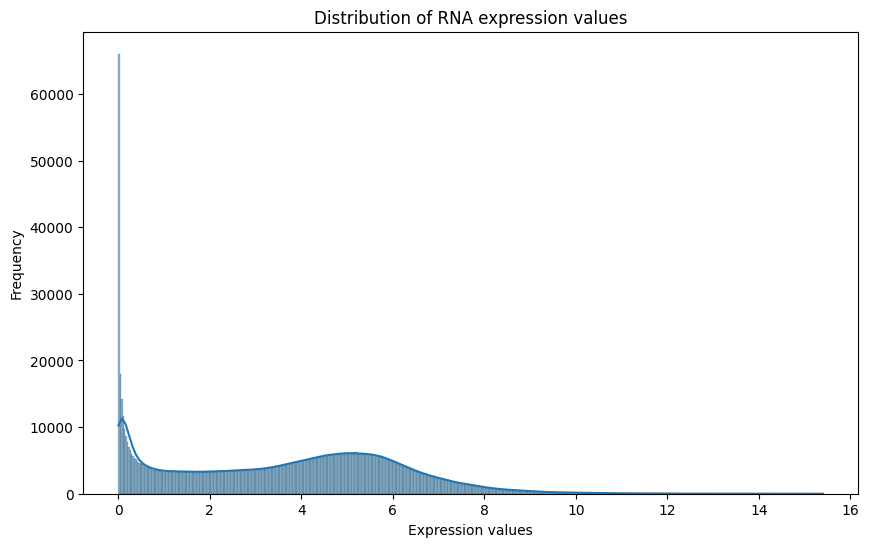

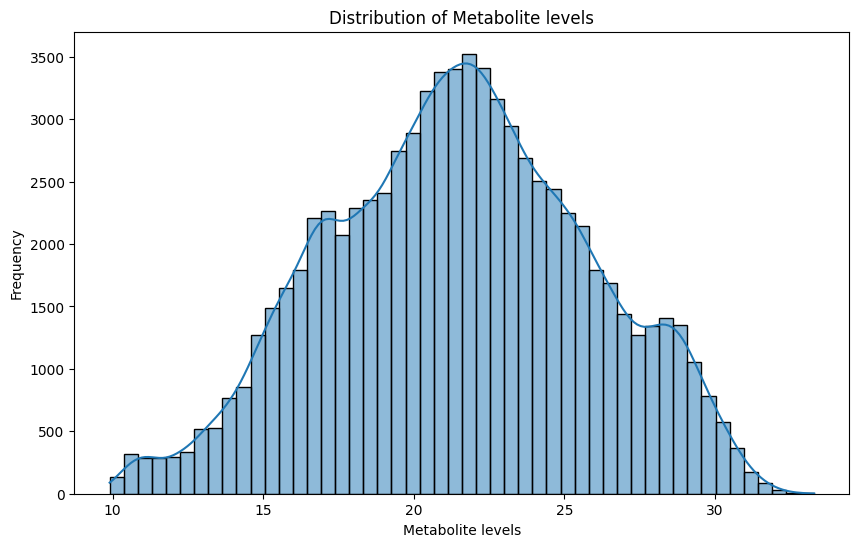

In [ ]:
# For RNA data
plt.figure(figsize=(10, 6))
sns.histplot(rna.values.ravel(), bins=500, kde=True)
plt.title("Distribution of RNA expression values")
plt.xlabel("Expression values")
plt.ylabel("Frequency")
plt.savefig(f'{results_path}/rna_sample_distribution.svg', bbox_inches = 'tight')
plt.show()

# For metabolite data
plt.figure(figsize=(10, 6))
sns.histplot(metabolites.values.ravel(), bins=50, kde=True)
plt.title("Distribution of Metabolite levels")
plt.xlabel("Metabolite levels")
plt.ylabel("Frequency")
plt.savefig(f'{results_path}/metabolite_sample_distribution.svg', bbox_inches = 'tight')
plt.show()

#Data shuffling

In [ ]:
combined_data = pd.concat([rna, metabolites], axis=1)
shuffled_data = combined_data.sample(frac=1, random_state=0)
shuffled_rna = shuffled_data[rna.columns]
shuffled_metabolites = shuffled_data[metabolites.columns]

rna = shuffled_rna
metabolites = shuffled_metabolites

#Splitting data

In [ ]:
metabolites = metabolites.dropna(axis=1, how='all')
metabolites

,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
MSKC-00434,21.285023,18.525291,22.269048,20.855532,21.779443,19.138145,21.777495,20.358169,18.307532,23.600749,...,23.974979,26.434593,28.780564,16.955614,25.670526,19.752243,21.883085,23.257026,17.927070,20.541972
MSKC-00599,21.432448,20.711543,23.279264,22.233235,20.343802,20.790091,22.666330,23.401804,17.401330,23.151891,...,23.305275,24.722436,27.803883,17.310068,25.329318,18.731647,21.079636,19.589256,23.056082,20.383993
C3L-01049,NaN,NaN,22.780000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.518000,NaN,24.190000,NaN,NaN,NaN,20.711000,19.080000,20.073000,20.495000
PT-R55F,NaN,NaN,19.865000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.518000,NaN,24.822000,NaN,NaN,NaN,20.034000,19.080000,17.590000,16.580000
CORN-01917,20.998193,16.383929,15.848521,16.142638,16.884597,16.935933,16.452565,17.499835,16.666834,17.377077,...,23.165640,17.370863,23.811908,11.709372,16.173690,15.113739,18.804981,16.929170,14.704887,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00573,21.507037,20.170568,23.464514,21.863913,20.410327,21.925463,22.573988,21.401446,18.125910,23.227247,...,24.240417,24.456906,27.759137,17.310068,24.691828,18.202928,20.660277,19.884748,23.225391,19.933129
MSKC-00401,21.616601,18.512438,23.028355,19.879137,18.660445,21.382817,18.433717,21.884295,18.396894,22.175226,...,25.032915,25.889804,29.394551,16.955614,25.631695,19.401777,24.751880,15.840222,18.946887,23.695717
MSKC-00305,20.798126,16.921797,21.582063,19.816563,20.749809,21.742109,22.721320,24.551645,20.016910,24.015005,...,25.372303,26.455923,29.386272,16.955614,26.067353,20.509021,23.013340,21.120513,15.471989,21.957202
CORN-01909,21.755531,17.240752,15.669045,17.072991,16.552940,17.895445,16.947653,16.625371,16.691284,17.877267,...,23.590241,17.644163,23.957294,12.010399,16.413830,16.737622,19.420232,14.248541,14.704887,NaN


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(rna, metabolites, test_size=0.2, random_state=0)

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer_train = SimpleImputer(strategy='mean')
y_train_imputed = imputer_train.fit_transform(y_train)

In [ ]:
imputer_test = SimpleImputer(strategy='mean')
y_test_imputed = imputer_test.fit_transform(y_test)

In [ ]:
y_train = pd.DataFrame(y_train_imputed, columns=y_train.columns, index=y_train.index)
y_test = pd.DataFrame(y_test_imputed, columns=y_test.columns, index=y_test.index)

In [ ]:
if y_train.isnull().any().any():
    print("DataFrame contains NaN values")
else:
    print("DataFrame does not contain NaN values")

DataFrame does not contain NaN values


In [ ]:
if y_test.isnull().any().any():
    print("DataFrame contains NaN values")
else:
    print("DataFrame does not contain NaN values")

DataFrame does not contain NaN values


In [ ]:
y_train_features = y_train.columns
y_train_features

Index(['1,5-anhydroglucitol (1,5-AG)', '1-arachidonoyl-GPC (20:4n6)',
       '1-arachidonoyl-GPE (20:4n6)', '1-arachidonoyl-GPI (20:4)',
       '1-linoleoylglycerol (18:2)', '1-linoleoyl-GPC (18:2)',
       '1-oleoylglycerol (1-monoolein)', '1-oleoyl-GPE (18:1)',
       '1-palmitoleoyl-GPC (16:1)', '1-palmitoylglycerol (1-monopalmitin)',
       ...
       'urea', 'uridine', 'valine', 'valylglycine', 'xanthine', 'xanthosine',
       '3-phosphoglycerate', 'dehydroascorbate', 'pyruvate',
       'phosphoenolpyruvate (PEP)'],
      dtype='object', length=218)

In [ ]:
import pickle

# Save the list to a file
with open('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/y_train_features.pkl', 'wb') as f:
    pickle.dump(y_train_features, f)

#Import sklearn modules

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import MultiTaskLasso
from sklearn.linear_model import MultiTaskElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

#Scoring and plotting functions

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

def get_r2_mse_rmse_plot_pred(data_y_test, model_predictions, model_type):

  r2 = r2_score(data_y_test, model_predictions)
  mse = mean_squared_error(data_y_test, model_predictions)
  rmse = mse**0.5

  print(f"R-squared: {r2}")
  print(f"Mean Squared Error (MSE): {mse}")
  print(f"Root Mean Squared Error (RMSE): {rmse}")


  plt.figure(figsize=(8, 6))
  for i in range(data_y_test.shape[1]):
      plt.scatter(data_y_test.iloc[:, i], model_predictions[:, i], alpha=0.5)

  plt.plot([data_y_test.min().min(), data_y_test.max().max()], [data_y_test.min().min(), data_y_test.max().max()], 'k--', lw=2, label='Ideal')

  plt.xlabel("Actual Values")
  plt.ylabel("Predicted Values")
  plt.title(f"Predicted vs. Actual Values for Metabolites ({model_type})")
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper right')
  plt.grid(True)
  plt.savefig(f'{results_path}/{model_type}.svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

def plot_cv_scores(model_pipeline, model_type,cv_fold):

  imputer_metabolites = SimpleImputer(strategy='mean')
  metabolites_imputed = imputer_metabolites.fit_transform(metabolites)
  metabolites_imputed = pd.DataFrame(metabolites_imputed, columns=metabolites.columns, index=metabolites.index)

  scores = cross_val_score(model_pipeline, rna, metabolites_imputed, cv=cv_fold, scoring='neg_mean_squared_error', n_jobs = -1)

  print("Cross-validation scores:", scores)
  print("Average score:", scores.mean())

  scores = pd.DataFrame(scores)
  scores = scores.rename(columns = {0: 'Cross-validation scores'})
  scores['Cross-validation fold'] = [i + 1 for i in range(len(scores))]

  sns.lineplot(data = scores, x = 'Cross-validation fold', y = 'Cross-validation scores')
  plt.ylabel('Negative MSE')
  plt.title('Negative MSE fluctuation with CV-fold')
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.savefig(f'{results_path}/MSE vs CV ({model_type}).svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
from sklearn.model_selection import KFold

def get_r2_cross_val(model, model_name):

  cv = KFold(n_splits=10, shuffle=True, random_state=0)

  scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2', n_jobs = -1)

  print("Cross-validation R-squared scores:", scores)
  print("Average R-squared score:", scores.mean())

  scores_df = pd.DataFrame({'Fold': range(1, len(scores) + 1), 'R-squared': scores})

  # Plot the scores
  plt.figure(figsize=(8, 6))
  sns.lineplot(x='Fold', y='R-squared', data=scores_df, marker='o')
  plt.title(f'Cross-validation R-squared scores for {model_name}')
  plt.xlabel('Fold')
  plt.ylabel('R-squared')
  plt.savefig(f'{results_path}/R2 vs CV ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

def get_metrics(y_predicted):

  mse = mean_squared_error(y_test, y_predicted)
  print("MSE:", mse)

  from sklearn.metrics import mean_absolute_error
  mae = mean_absolute_error(y_test, y_predicted)
  print("MAE:", mae)

  from sklearn.metrics import median_absolute_error
  medae = median_absolute_error(y_test, y_predicted,)
  print("MedAE:", medae)

  def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

  mape = mean_absolute_percentage_error(y_test, y_predicted)
  print('Mean absolute percentage error:', mape)

In [ ]:
from scipy.stats import spearmanr

def get_spearman_correlation(model_predictions, model_name):

  correlation, p_value = spearmanr(X_test, model_predictions)

  correlation_df = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': model_predictions.flatten()})

  # Calculate Spearman's correlation
  correlation, p_value = spearmanr(correlation_df['Actual'], correlation_df['Predicted'])

  # Add correlation and p-value to DataFrame
  correlation_df['Correlation'] = correlation
  correlation_df['P-value'] = p_value

  sns.regplot(x='Actual', y='Predicted', data=correlation_df, line_kws={'color': 'red'})
  plt.title(f'Spearman\'s Correlation ({model_name})')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  # Add correlation and p-value as text
  plt.text(0.1, 0.9, f'Correlation: {correlation:.2f}\nP-value: {p_value:.2f}', transform=plt.gca().transAxes)
  plt.savefig(f'{results_path}/Spearmans Corr ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
#Checking for heteroscedasticity
!pip install statsmodels

import statsmodels.api as sm

def get_residuals_vs_pred_plot(model_predictions, model_name):

  residuals = (y_test - model_predictions).values.ravel()

  plt.figure(figsize=(8, 6))
  plt.scatter(model_predictions.ravel(), residuals, alpha=0.6)
  plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
  plt.title(f"Residuals vs. Predicted Values ({model_name})")
  plt.xlabel("Predicted Values")
  plt.ylabel("Residuals")
  plt.savefig(f'{results_path}/Residuals vs Pred Values ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
def plot_r2_per_metabolite(model, model_name, X_test, y_test):
    """Plots the R2 score per metabolite for a given model in descending order."""

    y_pred = model.predict(X_test)  # Get model predictions

    r2_scores = []  # Initialize list to store R2 scores
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])  # Calculate R2 for the current metabolite
        r2_scores.append(r2)  # Add the R2 score to the list

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': y_test.columns, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.bar(range(len(r2_df)), r2_df['R2 Score'])  # Create bar plot of R2 scores
    plt.xticks()  # Set x-axis labels to metabolite names
    plt.xlabel("Metabolite")
    plt.ylabel("R2 Score")
    plt.title(f"R2 Score per Metabolite ({model_name}) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig(f'{results_path}/R2 per metabolite ({model_name}).svg', bbox_inches = 'tight')
    plt.show()

In [ ]:
def get_r2_per_metabolite(model, model_name, X_test, y_test):
    """Get the R2 score per metabolite for a given model in descending order."""

    y_pred = model.predict(X_test)  # Get model predictions

    r2_scores = []  # Initialize list to store R2 scores
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])  # Calculate R2 for the current metabolite
        r2_scores.append(r2)  # Add the R2 score to the list

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': y_test.columns, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)

    return r2_df

In [ ]:
from scipy.stats import spearmanr

def plot_spearman_per_metabolite(model, model_name, X_test, y_test):
    """Plots the Spearman's correlation coefficient per metabolite for a given model."""

    y_pred = model.predict(X_test)  # Get model predictions

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        coeff, _ = spearmanr(y_test.iloc[:, i], y_pred[:, i])  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting
    spearman_df = pd.DataFrame({'Metabolite': y_test.columns, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.bar(range(len(spearman_df)), spearman_df['Spearman Coefficient'])  # Create bar plot of coefficients
    plt.xticks()  # Set x-axis labels to metabolite names
    plt.xlabel("Metabolite")
    plt.ylabel("Spearman's Coefficient")
    plt.title(f"Spearman's Correlation Coefficient per Metabolite ({model_name}) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig(f'{results_path}/Spearman per metabolite ({model_name}).svg', bbox_inches = 'tight')
    plt.show()

In [ ]:
def get_spearman_per_metabolite(model, model_name, X_test, y_test):
    """Get the Spearman's correlation coefficient per metabolite for a given model."""

    y_pred = model.predict(X_test)  # Get model predictions

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        coeff, _ = spearmanr(y_test.iloc[:, i], y_pred[:, i])  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting
    spearman_df = pd.DataFrame({'Metabolite': y_test.columns, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)

    return spearman_df

In [ ]:
import joblib

def save_model(model, model_name):
    joblib.dump(model, f'{results_path}/{model_name}.pkl')

#Ridge

In [ ]:
pipeline_ridge = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95,)),
    ('model', Ridge(random_state = 0))
                          ])

In [ ]:
param_grid_ridge = {
    'model__alpha' : [0.1, 10, 100, 200, 300, 325, 350, 375, 400, 450, 500, 750, 1000]
}

In [ ]:
grid_search_ridge = GridSearchCV(
    pipeline_ridge,
    param_grid_ridge,
    cv = 5,
    scoring = 'neg_mean_squared_error',
    n_jobs = -1
)

grid_search_ridge.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model', Ridge(random_state=0))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.1, 10, 100, 200, 300, 325, 350, 375,
                                          400, 450, 500, 750, 1000]},
             scoring='neg_mean_squared_error')

In [ ]:
print("Best hyperparameters:", grid_search_ridge.best_params_)
print("Best score:", grid_search_ridge.best_score_)

Best hyperparameters: {'model__alpha': 450}
Best score: -2.523646482252198


In [ ]:
best_ridge_model = grid_search_ridge.best_estimator_

In [ ]:
save_model(model = best_ridge_model, model_name = 'Ridge')

In [ ]:
ridge_predictions = best_ridge_model.predict(X_test)

Cross-validation scores: [-2.15998301 -2.46215113 -2.38554552 -2.38508158 -2.01470294 -2.4671968
 -2.48710119 -2.45733222 -2.48651482 -2.67630817]
Average score: -2.398191738304245


/tmp/ipython-input-2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


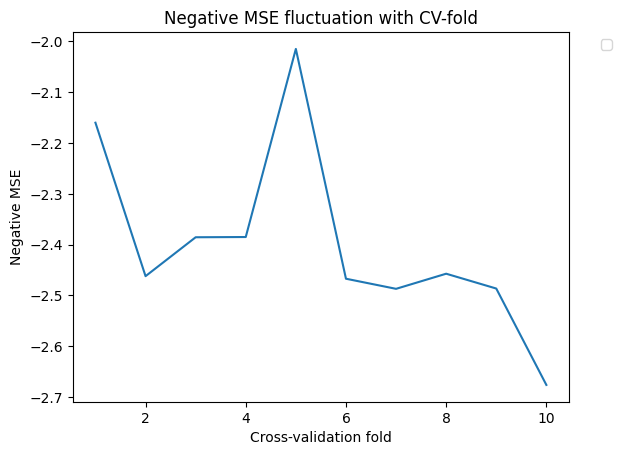

In [ ]:
plot_cv_scores(model_pipeline = best_ridge_model, model_type = 'Ridge', cv_fold = 10)

R-squared: 0.5440844268158948
Mean Squared Error (MSE): 2.8190496690282854
Root Mean Squared Error (RMSE): 1.6790025816026268


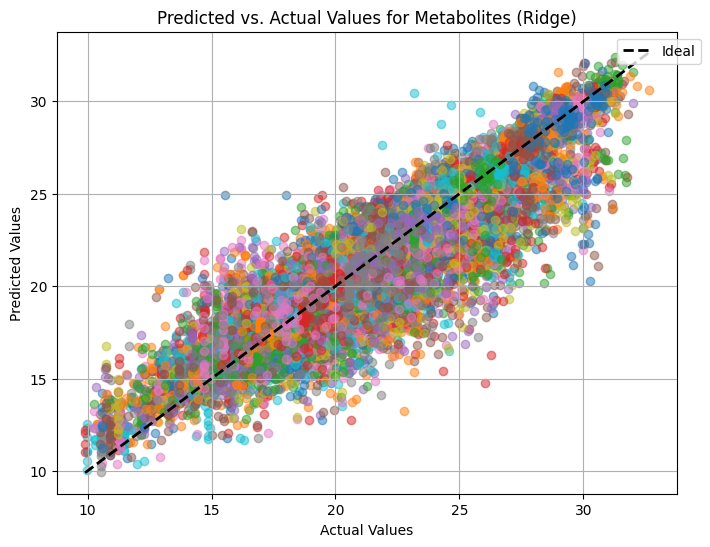

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = ridge_predictions, model_type = 'Ridge')

Cross-validation R-squared scores: [0.62874223 0.55647194 0.6278242  0.57755683 0.67426469 0.58710907
 0.57425913 0.66032661 0.61206049 0.54683   ]
Average R-squared score: 0.6045445170002531


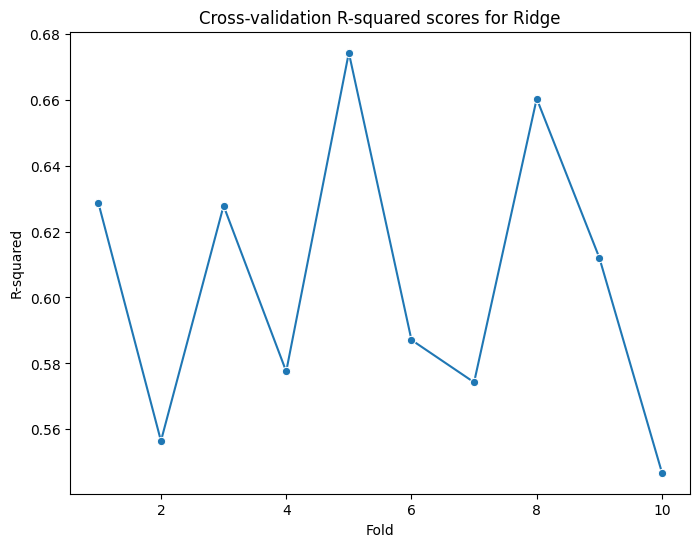

In [ ]:
get_r2_cross_val(model = best_ridge_model, model_name = 'Ridge')

In [ ]:
get_metrics(y_predicted = ridge_predictions)

MSE: 2.8190496690282854
MAE: 1.1406046977233895
MedAE: 0.7548578767853323
Mean absolute percentage error: 5.57472699720571


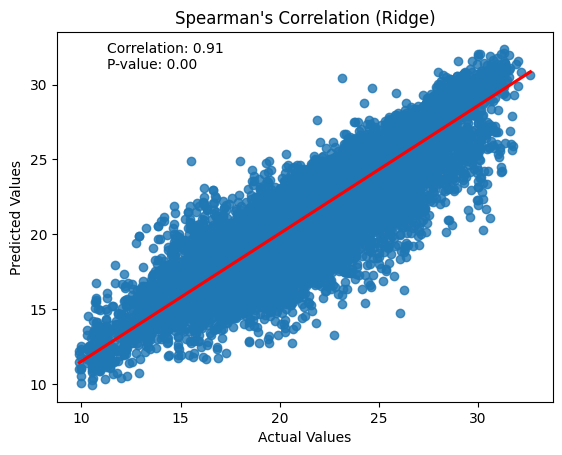

In [ ]:
get_spearman_correlation(model_predictions = ridge_predictions, model_name = 'Ridge')

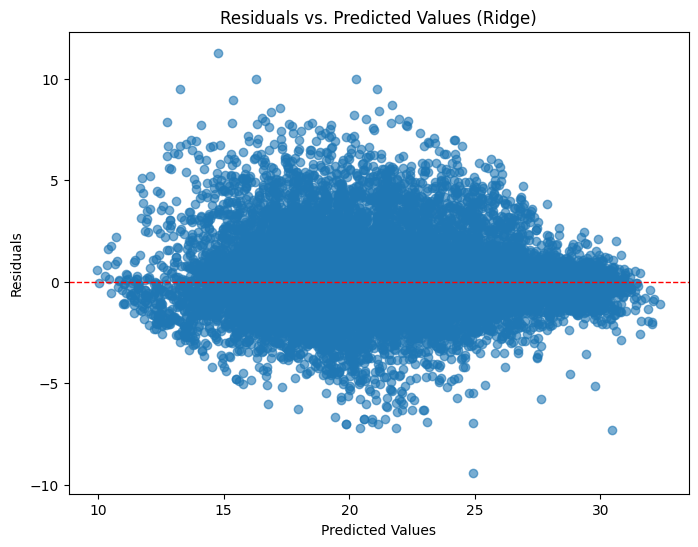

In [ ]:
get_residuals_vs_pred_plot(model_predictions = ridge_predictions, model_name = 'Ridge')

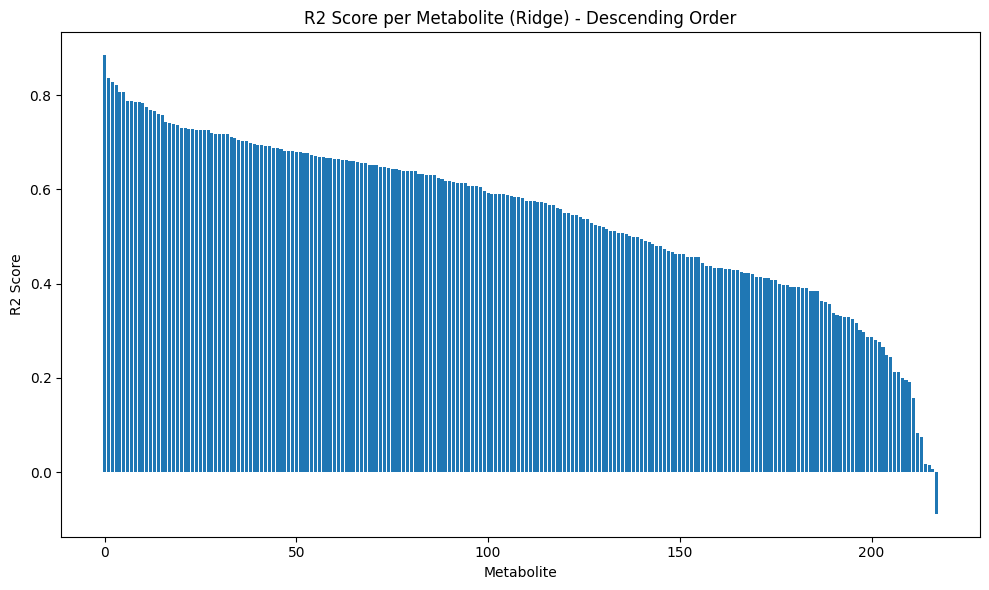

In [ ]:
plot_r2_per_metabolite(best_ridge_model, "Ridge", X_test, y_test)

In [ ]:
r2_ridge = get_r2_per_metabolite(best_ridge_model, 'Ridge', X_test, y_test)
r2_ridge

,Metabolite,R2 Score
205,tyrosine,0.884501
195,stearoyl sphingomyelin (d18:1/18:0),0.835652
120,hippurate,0.828087
11,1-palmitoyl-GPE (16:0),0.822013
128,isoleucine,0.807180
...,...,...
160,N6-acetyllysine,0.075063
50,alanylleucine,0.016924
135,lidocaine,0.015847
126,inositol 1-phosphate (I1P),0.006624


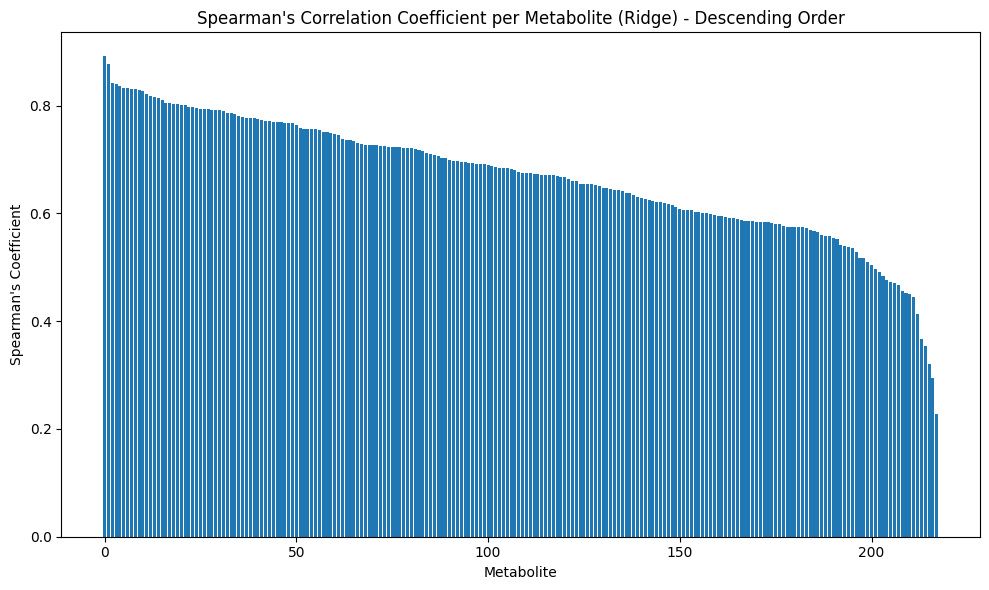

In [ ]:
plot_spearman_per_metabolite(best_ridge_model, 'Ridge', X_test, y_test)

In [ ]:
spearman_ridge = get_spearman_per_metabolite(best_ridge_model, 'Ridge', X_test, y_test)
spearman_ridge

,Metabolite,Spearman Coefficient
120,hippurate,0.891575
72,creatinine,0.877603
131,lactate,0.842229
166,4-acetamidophenylglucuronide,0.840548
175,phenylacetylglutamine,0.836603
...,...,...
97,gamma-glutamylphenylalanine,0.366768
88,erythritol,0.354282
0,"1,5-anhydroglucitol (1,5-AG)",0.319920
103,"glutamate, gamma-methyl ester",0.294486


In [ ]:
r2_ridge.to_csv(f'{results_path}/r2_ridge.csv', index = False)

In [ ]:
spearman_ridge.to_csv(f'{results_path}/spearman_ridge.csv', index = False)

#Multi-task Lasso

In [ ]:
pipeline_multi_lasso = Pipeline([
                                ('imputer', SimpleImputer(strategy='mean')),
                                ('scaler', StandardScaler()),
                                ('pca', PCA(0.95,)),
                                ('model', MultiTaskLasso(random_state = 0))
                                ])

In [ ]:
param_grid_lasso = {
                    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100] # Example values for alpha
                   }

grid_search_lasso = GridSearchCV(pipeline_multi_lasso, param_grid_lasso, cv=10, scoring='neg_mean_squared_error', n_jobs = -1)
grid_search_lasso.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model',
                                        MultiTaskLasso(random_state=0))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='neg_mean_squared_error')

In [ ]:
print("Best hyperparameters:", grid_search_lasso.best_params_)
print("Best score:", grid_search_lasso.best_score_)

Best hyperparameters: {'model__alpha': 1}
Best score: -2.517328261874836


In [ ]:
best_lasso_model = grid_search_lasso.best_estimator_

In [ ]:
lasso_predictions = best_lasso_model.predict(X_test)

In [ ]:
save_model(model = best_lasso_model, model_name = 'Lasso')

Cross-validation scores: [-2.18692813 -2.45927123 -2.3794151  -2.42485529 -2.01552838 -2.46811386
 -2.46283316 -2.47050348 -2.50093092 -2.68788491]
Average score: -2.405626445766052


/tmp/ipython-input-2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


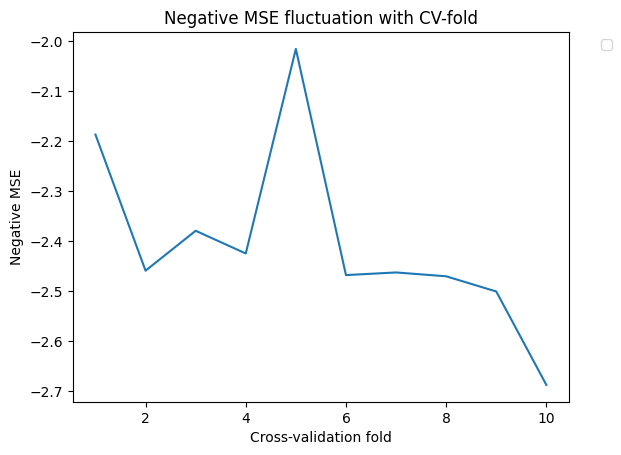

In [ ]:
plot_cv_scores(model_pipeline = best_lasso_model, model_type = 'Multi-task Lasso', cv_fold = 10)

R-squared: 0.5473890781576765
Mean Squared Error (MSE): 2.799342485392797
Root Mean Squared Error (RMSE): 1.6731235714652988


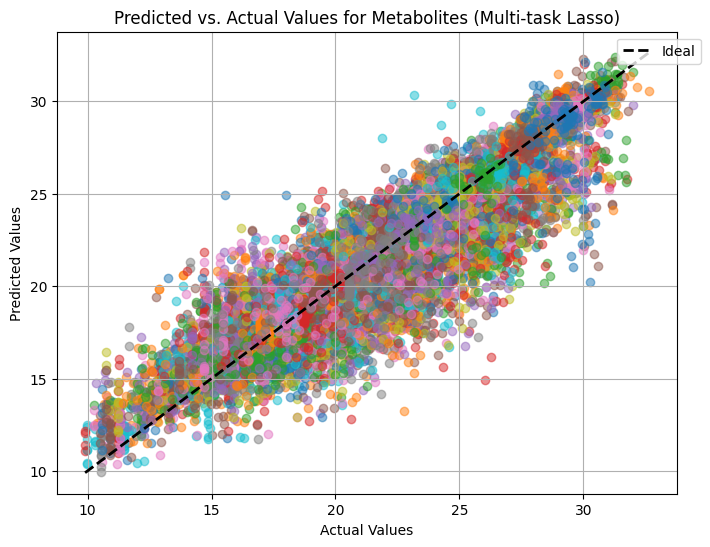

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = lasso_predictions, model_type = 'Multi-task Lasso')

Cross-validation R-squared scores: [0.62823478 0.55492058 0.6274196  0.5758042  0.67928693 0.58706331
 0.57540375 0.65845543 0.61390684 0.55293234]
Average R-squared score: 0.6053427758139327


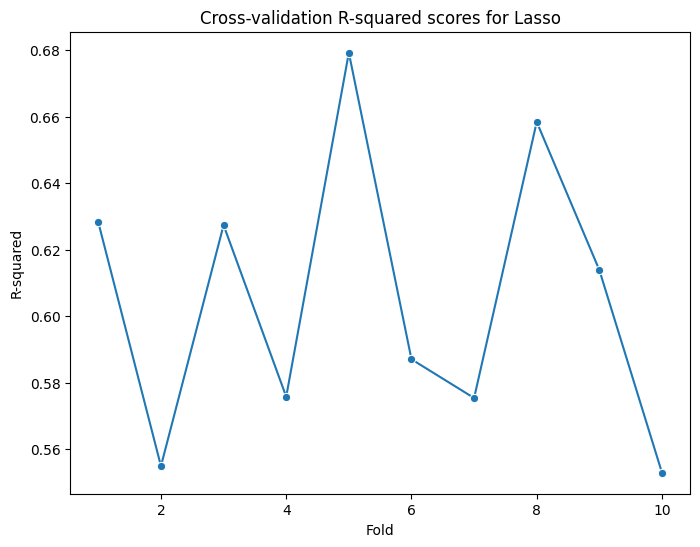

In [ ]:
get_r2_cross_val(model = best_lasso_model, model_name = 'Lasso')

In [ ]:
get_metrics(y_predicted = lasso_predictions)

MSE: 2.799342485392797
MAE: 1.1372709148234175
MedAE: 0.7535193899024795
Mean absolute percentage error: 5.555949342370531


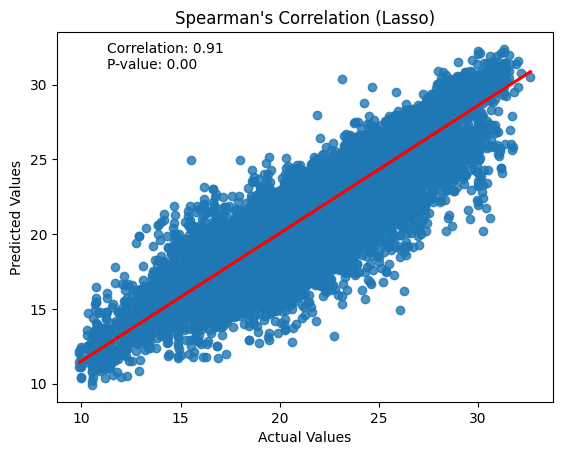

In [ ]:
get_spearman_correlation(model_predictions = lasso_predictions, model_name = 'Lasso')

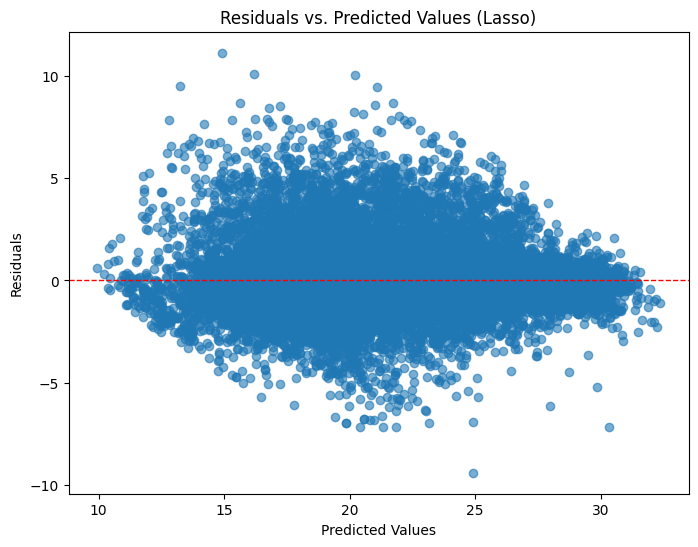

In [ ]:
get_residuals_vs_pred_plot(model_predictions = lasso_predictions, model_name = 'Lasso')

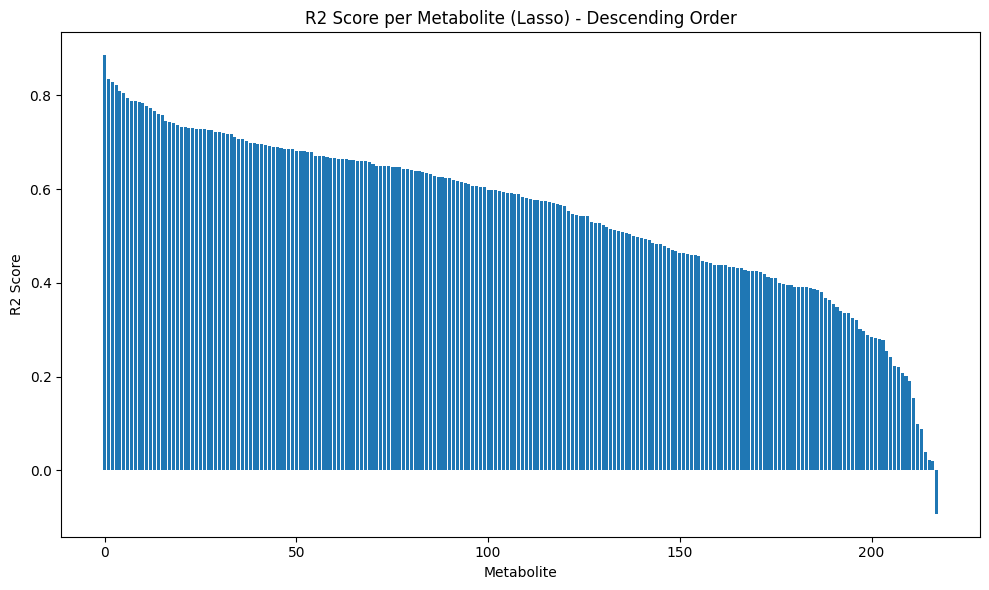

In [ ]:
plot_r2_per_metabolite(best_lasso_model, "Lasso", X_test, y_test)

In [ ]:
r2_lasso = get_r2_per_metabolite(best_lasso_model, 'Lasso', X_test, y_test)
r2_lasso

,Metabolite,R2 Score
205,tyrosine,0.885481
195,stearoyl sphingomyelin (d18:1/18:0),0.834272
120,hippurate,0.828254
11,1-palmitoyl-GPE (16:0),0.821961
128,isoleucine,0.810051
...,...,...
202,thymine,0.088464
135,lidocaine,0.038261
50,alanylleucine,0.021806
126,inositol 1-phosphate (I1P),0.020679


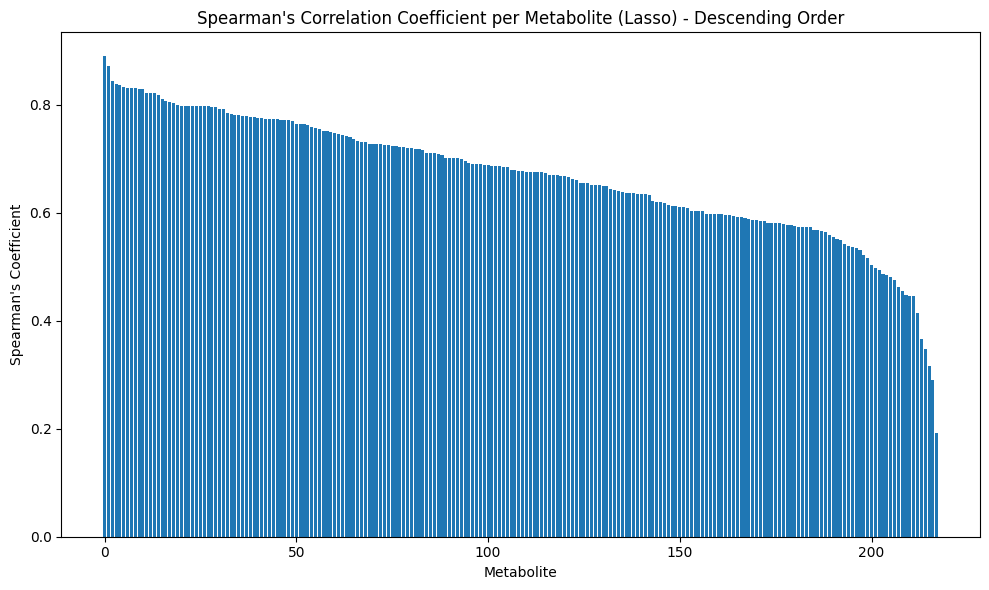

In [ ]:
plot_spearman_per_metabolite(best_lasso_model, 'Lasso', X_test, y_test)

In [ ]:
spearman_lasso = get_spearman_per_metabolite(best_lasso_model, 'Lasso', X_test, y_test)
spearman_lasso

,Metabolite,Spearman Coefficient
120,hippurate,0.889268
72,creatinine,0.871492
175,phenylacetylglutamine,0.843285
166,4-acetamidophenylglucuronide,0.837177
131,lactate,0.836716
...,...,...
88,erythritol,0.366010
97,gamma-glutamylphenylalanine,0.348048
0,"1,5-anhydroglucitol (1,5-AG)",0.315890
103,"glutamate, gamma-methyl ester",0.290615


In [ ]:
r2_lasso.to_csv(f'{results_path}/r2_lasso.csv', index = False)
spearman_lasso.to_csv(f'{results_path}/spearman_lasso.csv', index = False)

#Multi-task Elastic-Net

In [ ]:
pipeline_elasticnet = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('model', MultiTaskElasticNet(random_state = 0))
])

In [ ]:
param_grid_elasticnet = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__l1_ratio': [0.1, 0.5, 0.9]
}

In [ ]:
grid_search_elasticnet = GridSearchCV(
                                      pipeline_elasticnet,
                                      param_grid_elasticnet,
                                      cv=10,
                                      scoring='neg_mean_squared_error',
                                      n_jobs = -1
                                      )
grid_search_elasticnet.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model',
                                        MultiTaskElasticNet(random_state=0))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
                         'model__l1_ratio': [0.1, 0.5, 0.9]},
             scoring='neg_mean_squared_error')

In [ ]:
print("Best hyperparameters for ElasticNet:", grid_search_elasticnet.best_params_)
print("Best score for ElasticNet:", grid_search_elasticnet.best_score_)

Best hyperparameters for ElasticNet: {'model__alpha': 1, 'model__l1_ratio': 0.5}
Best score for ElasticNet: -2.5132584751168254


In [ ]:
best_elasticnet_model = grid_search_elasticnet.best_estimator_

In [ ]:
elasticnet_predictions = best_elasticnet_model.predict(X_test)

In [ ]:
save_model(model = best_elasticnet_model, model_name = 'ElasticNet')

Cross-validation scores: [-2.16087662 -2.45319501 -2.37849994 -2.3913072  -2.01270977 -2.45673938
 -2.48158937 -2.45737527 -2.49289504 -2.67871064]
Average score: -2.3963898233233474


/tmp/ipython-input-2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


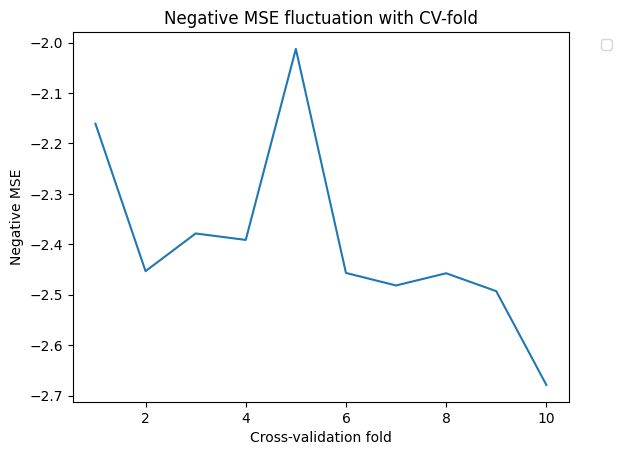

In [ ]:
plot_cv_scores(model_pipeline = best_elasticnet_model, model_type = 'Multi-task Elastic Net (All metabolites)', cv_fold = 10)

R-squared: 0.5472575037972841
Mean Squared Error (MSE): 2.796078872979999
Root Mean Squared Error (RMSE): 1.6721479817827125


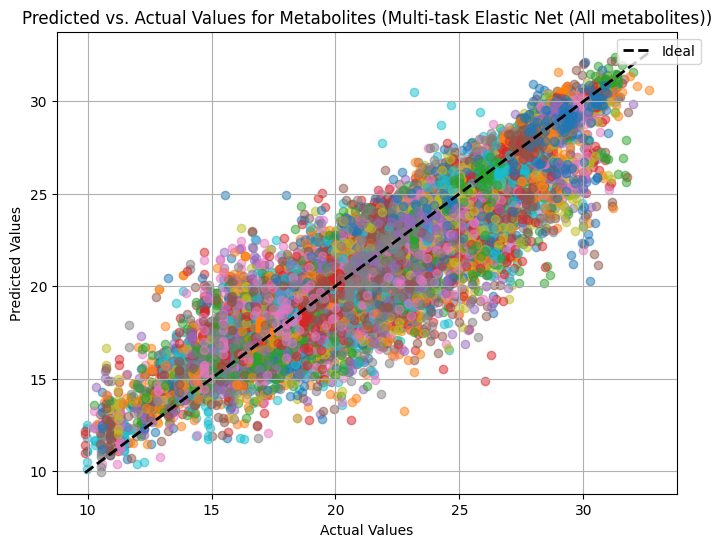

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = elasticnet_predictions, model_type = 'Multi-task Elastic Net (All metabolites)')

Cross-validation R-squared scores: [0.62760396 0.55184468 0.62740474 0.57554986 0.67682145 0.58882189
 0.57499488 0.66001774 0.6132491  0.54822611]
Average R-squared score: 0.6044534403893724


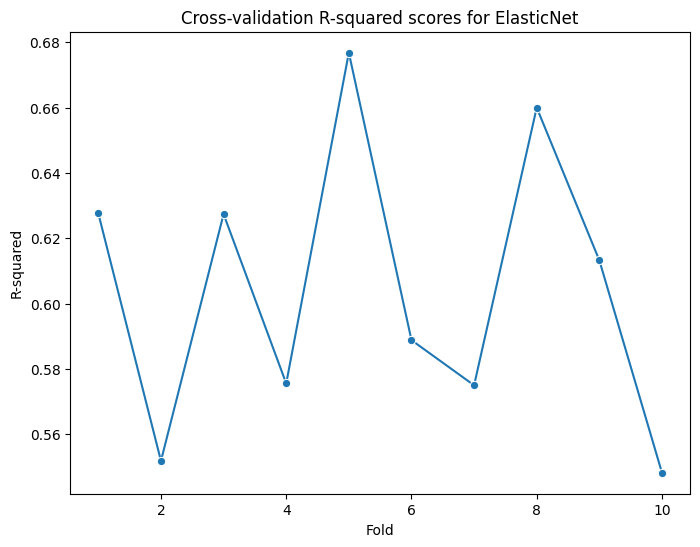

In [ ]:
get_r2_cross_val(model = best_elasticnet_model, model_name = 'ElasticNet')

In [ ]:
get_metrics(y_predicted = elasticnet_predictions)

MSE: 2.796078872979999
MAE: 1.1367962341729156
MedAE: 0.7542216316471733
Mean absolute percentage error: 5.554989087301935


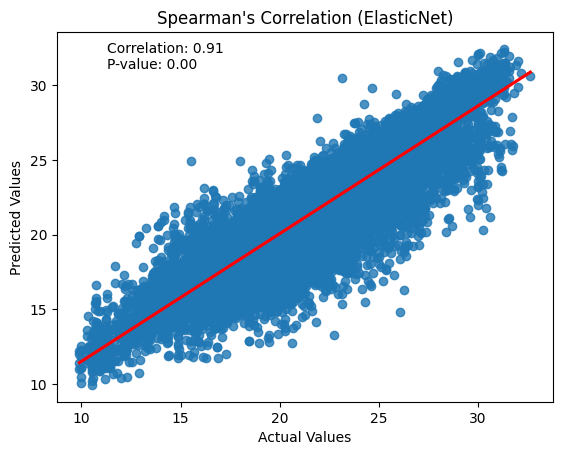

In [ ]:
get_spearman_correlation(model_predictions = elasticnet_predictions, model_name = 'ElasticNet')

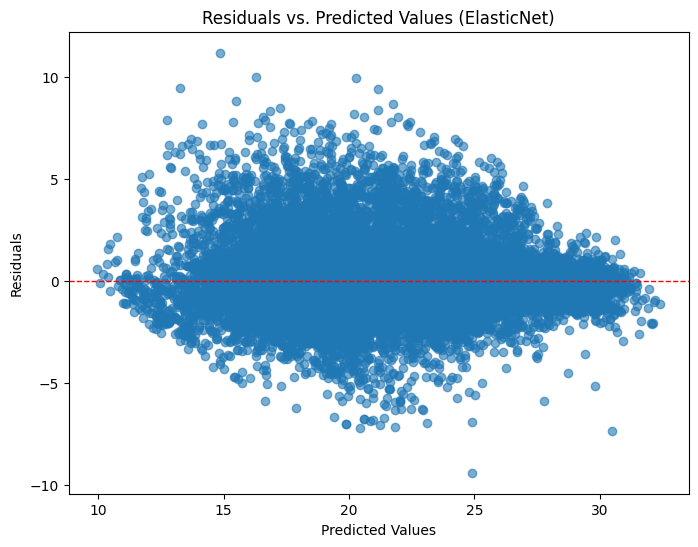

In [ ]:
get_residuals_vs_pred_plot(model_predictions = elasticnet_predictions, model_name = 'ElasticNet')

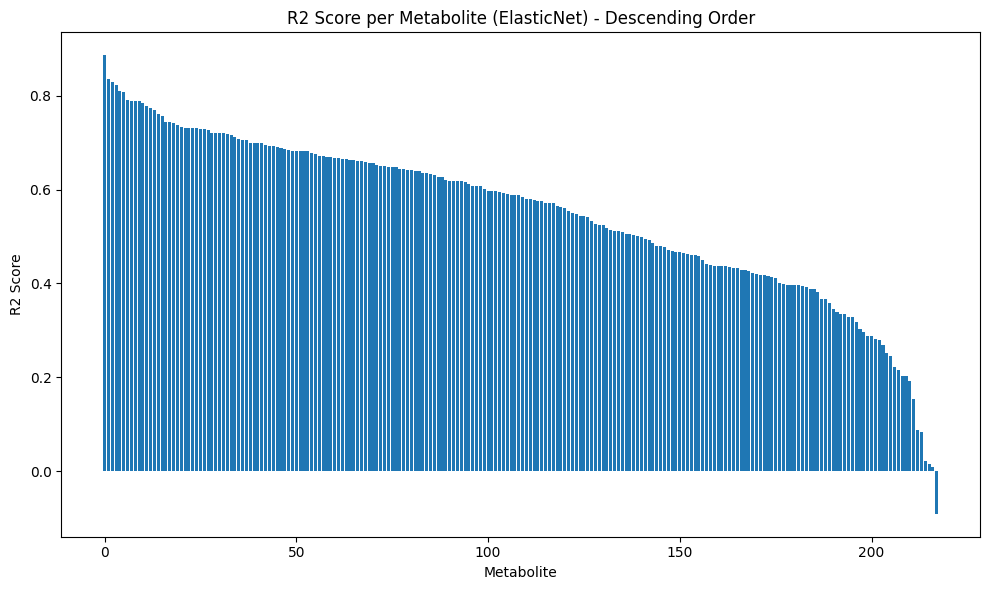

In [ ]:
plot_r2_per_metabolite(best_elasticnet_model, "ElasticNet", X_test, y_test)

In [ ]:
y_test.to_csv(f'{results_path}/y_test_elasticnet_model.csv', index = True)

In [ ]:
elasticnet_predictions = pd.DataFrame(elasticnet_predictions, index = y_test.index, columns = y_test.columns)
elasticnet_predictions

,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
CORN-01907,19.894554,17.448066,16.909893,17.108638,16.540170,18.168868,17.619623,16.851126,16.942445,18.831820,...,22.249656,18.430332,23.719121,13.961329,16.772311,17.310401,17.153513,15.482961,14.440343,19.843172
C3N-01364,21.209230,18.423676,21.980199,19.914339,19.818077,20.813714,20.950456,21.192015,18.444855,21.842689,...,17.701205,23.974777,24.947395,16.782854,23.936556,18.922391,21.650183,19.483669,18.455831,18.851075
MSKC-00437,21.483383,17.987252,19.155060,18.592190,17.700287,20.097253,18.437893,18.975305,17.399502,20.006829,...,24.491511,21.930379,26.335597,17.079922,21.941784,17.049939,20.885014,18.585781,18.381821,18.378305
MSKC-00436,21.353352,18.646197,20.177656,19.001163,17.568678,19.454331,18.847475,20.216290,17.057141,20.155528,...,24.514190,21.528259,26.146704,17.145016,21.881447,18.431287,21.147520,17.648182,19.334561,19.019731
CORN-02038,20.521492,17.649592,16.052886,16.898227,15.852913,18.194329,17.102188,16.807425,16.495269,18.196341,...,22.074915,17.517261,23.239612,13.963028,16.656545,16.997075,15.769534,14.262676,15.569578,19.823137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DIAG-16106,21.117074,17.457800,18.425032,17.625645,17.283877,19.699289,18.465854,17.693516,17.008023,19.565863,...,23.834112,20.942829,25.033451,16.729970,21.108243,15.673469,21.065724,19.787295,17.029862,17.891803
MSKC-00299,21.942117,18.498518,22.918786,21.407127,20.713185,20.586815,21.350228,22.500621,18.496202,22.850078,...,24.844665,26.611691,29.186528,18.150199,26.644008,20.106904,23.715587,21.385524,20.493357,21.697764
DIAG-16080,20.984194,17.468846,18.412656,17.331805,16.646712,20.056599,18.641919,17.969809,16.555108,19.644031,...,24.021408,20.415471,24.350105,17.009452,20.488091,15.184216,20.212740,19.101820,17.981388,16.832620
DIAG-16150,21.110746,18.837708,18.784601,17.977091,17.268094,20.008432,18.673985,18.030935,16.941620,19.874815,...,23.768931,19.640545,24.616041,17.523962,19.976752,15.998937,19.737490,18.938369,19.078676,16.369656


In [ ]:
elasticnet_predictions.to_csv(f'{results_path}/predictions_elasticnet_model.csv', index = True)

In [ ]:
r2_elastic = get_r2_per_metabolite(best_elasticnet_model, 'ElasticNet', X_test, y_test)
r2_elastic

,Metabolite,R2 Score
205,tyrosine,0.886213
195,stearoyl sphingomyelin (d18:1/18:0),0.835572
120,hippurate,0.829232
11,1-palmitoyl-GPE (16:0),0.822614
128,isoleucine,0.810712
...,...,...
160,N6-acetyllysine,0.083156
135,lidocaine,0.022007
50,alanylleucine,0.015360
126,inositol 1-phosphate (I1P),0.008264


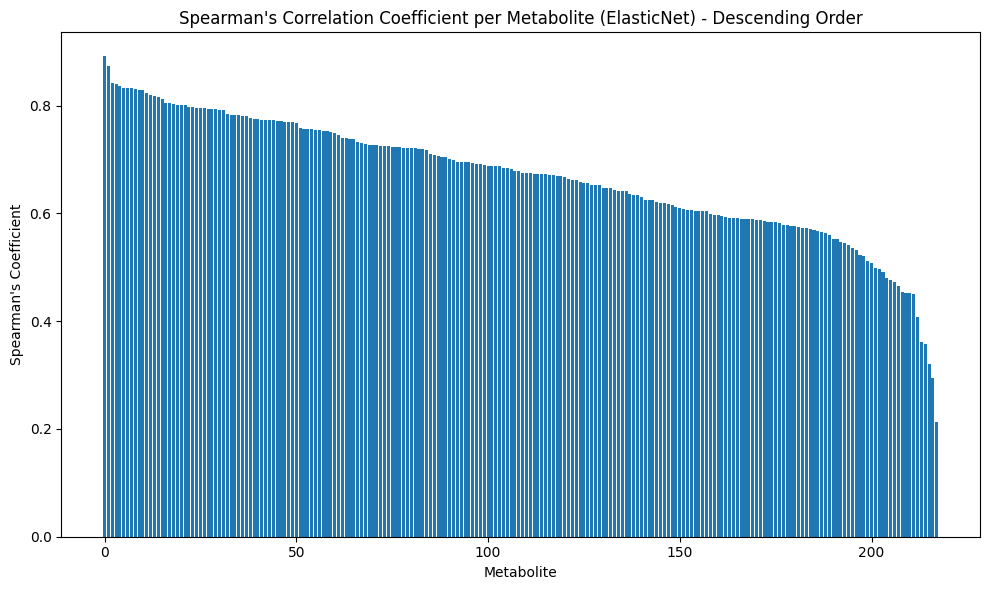

In [ ]:
plot_spearman_per_metabolite(best_elasticnet_model, 'ElasticNet', X_test, y_test)

In [ ]:
spearman_elastic = get_spearman_per_metabolite(best_elasticnet_model, 'ElasticNet', X_test, y_test)
spearman_elastic

,Metabolite,Spearman Coefficient
120,hippurate,0.891566
72,creatinine,0.874081
131,lactate,0.842088
166,4-acetamidophenylglucuronide,0.840503
175,phenylacetylglutamine,0.837381
...,...,...
97,gamma-glutamylphenylalanine,0.361303
88,erythritol,0.356845
0,"1,5-anhydroglucitol (1,5-AG)",0.320309
103,"glutamate, gamma-methyl ester",0.295334


In [ ]:
r2_elastic.to_csv(f'{results_path}/r2_elastic.csv', index = False)
spearman_elastic.to_csv(f'{results_path}/spearman_elastic.csv', index = False)

#Random Forest Regressor

In [ ]:
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('model', MultiOutputRegressor(RandomForestRegressor(n_estimators = 500, max_depth = 30, random_state=0, n_jobs = -1)))
])

model_rf = pipeline_rf.fit(X_train, y_train)

In [ ]:
# pipeline_rf = Pipeline([
#     ('imputer', SimpleImputer(strategy='mean')),
#     ('scaler', StandardScaler()),
#     ('pca', PCA(0.95)),
#     ('model', MultiOutputRegressor(RandomForestRegressor(random_state=0, n_jobs = -1)))
# ])

In [ ]:
# rf_param_grid = {
#     'model__estimator__n_estimators' : [100, 150, 200, 250, 300, 500],
#     'model__estimator__max_depth': [5, 10, 20, 30, 50]
# }

In [ ]:
# grid_search_rf = GridSearchCV(
#                               pipeline_rf,
#                               rf_param_grid,
#                               cv = 5,
#                               scoring = 'neg_mean_squared_error',
#                               verbose = 3,
#                               n_jobs = -1
#                               )

In [ ]:
# grid_search_rf.fit(X_train, y_train)

In [ ]:
# print("Best hyperparameters for RF:", grid_search_rf.best_params_)
# print("Best score for RF:", grid_search_rf.best_score_)

In [ ]:
# model_rf = grid_search_rf.best_estimator_

In [ ]:
save_model(model = model_rf, model_name = 'Random Forest Regressor')

In [ ]:
predictions_rf = model_rf.predict(X_test)

R-squared: 0.6575752707304166
Mean Squared Error (MSE): 2.3802594432303987
Root Mean Squared Error (RMSE): 1.542808945796724


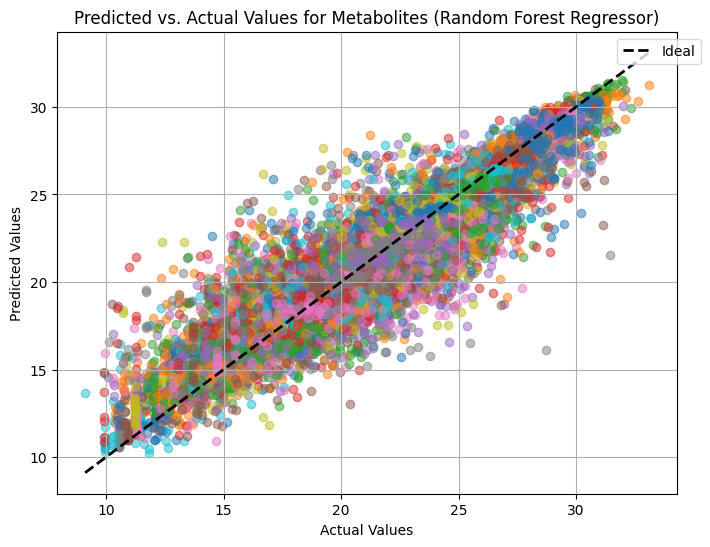

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = predictions_rf, model_type = 'Random Forest Regressor')

Cross-validation scores: [-2.82186069 -1.85837655 -3.1552553  -2.17766045 -3.33734246 -3.67917941
 -2.6675766  -2.99449689 -1.88021976 -2.7713866 ]
Average score: -2.7343354713093078


/tmp/ipython-input-2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


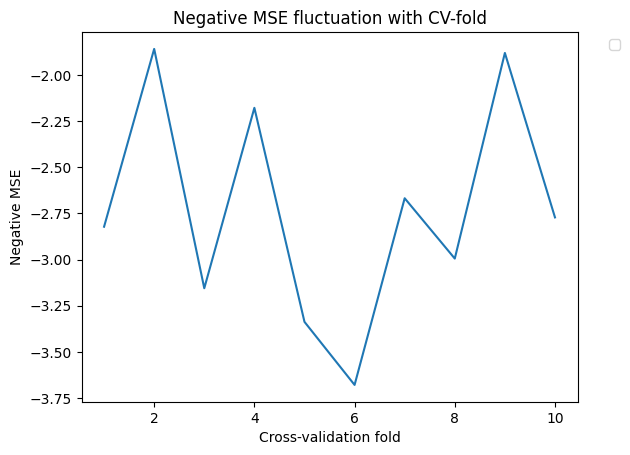

In [ ]:
plot_cv_scores(model_pipeline = model_rf, model_type = 'Multi-output Random Forest Regressor', cv_fold = 10)

In [ ]:
get_metrics(y_predicted = predictions_rf)

MSE: 2.3802594432303987
MAE: 1.0735880063406407
MedAE: 0.7785688568037651
Mean absolute percentage error: 5.543870062090087


Cross-validation R-squared scores: [0.44263737 0.60168106 0.66323507 0.63810044 0.38434508 0.49420966
 0.55327786 0.40615244 0.49020941 0.4861412 ]
Average R-squared score: 0.5159989594651115


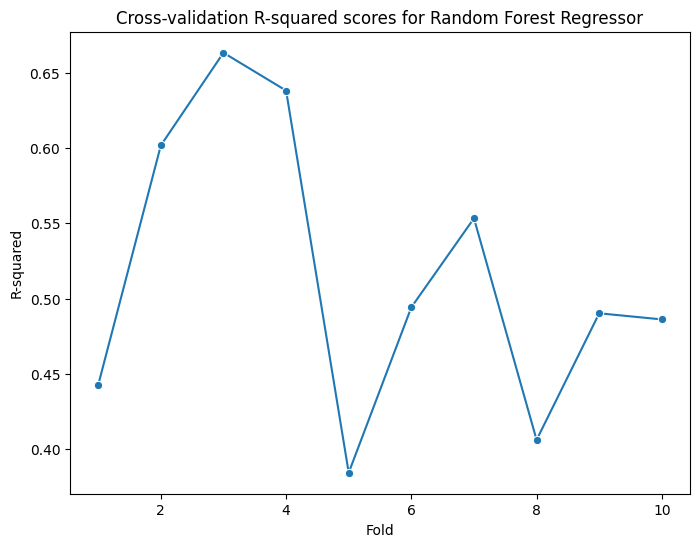

In [ ]:
get_r2_cross_val(model = model_rf, model_name = 'Random Forest Regressor')

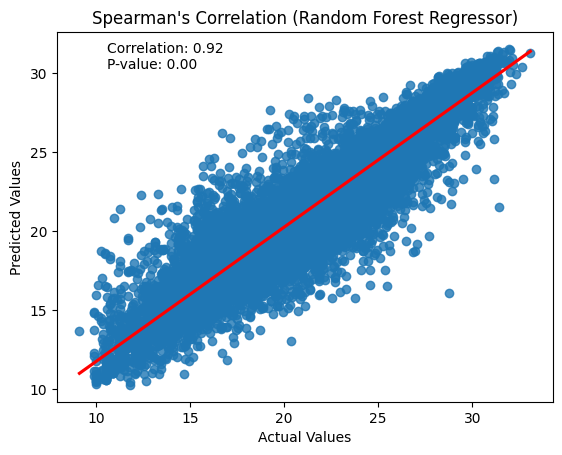

In [ ]:
get_spearman_correlation(model_predictions = predictions_rf, model_name = 'Random Forest Regressor')

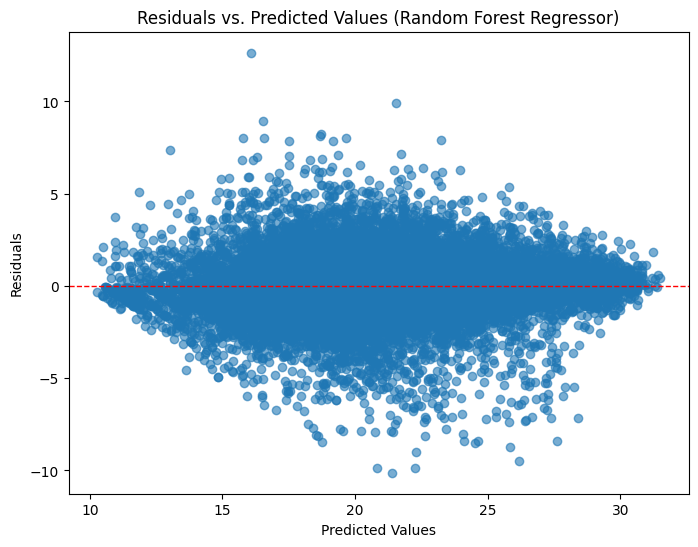

In [ ]:
get_residuals_vs_pred_plot(model_predictions = predictions_rf, model_name = 'Random Forest Regressor')

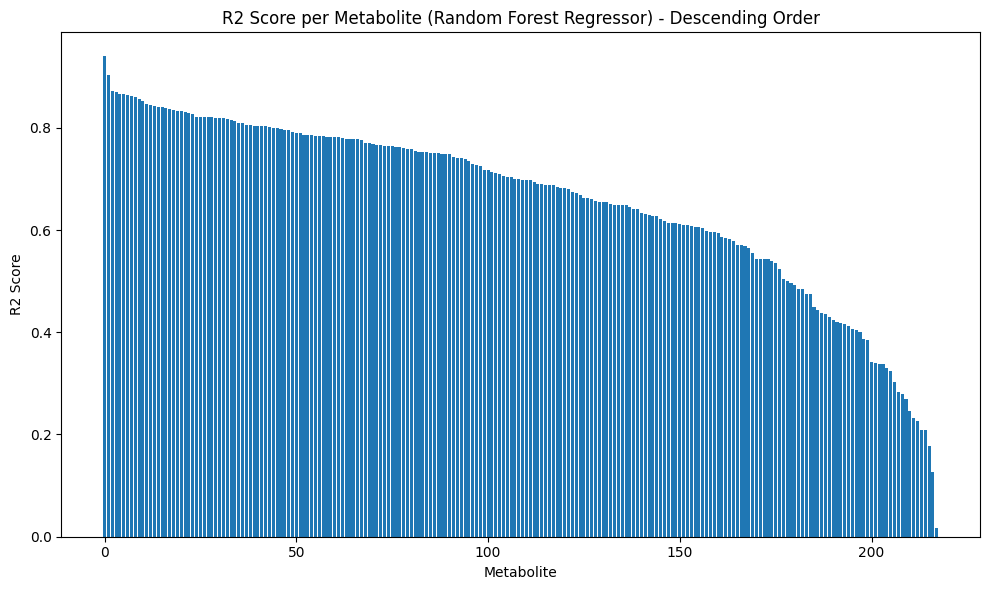

In [ ]:
plot_r2_per_metabolite(model_rf, "Random Forest Regressor", X_test, y_test)

In [ ]:
r2_rf = get_r2_per_metabolite(model_rf, "Random Forest Regressor", X_test, y_test)
r2_rf

,Metabolite,R2 Score
205,tyrosine,0.939818
201,threonine,0.904071
102,glutamate,0.871523
176,phenylalanine,0.869640
133,leucine,0.866640
...,...,...
147,myo-inositol,0.208718
107,"glutathione, reduced (GSH)",0.208009
106,"glutathione, oxidized (GSSG)",0.177350
126,inositol 1-phosphate (I1P),0.126397


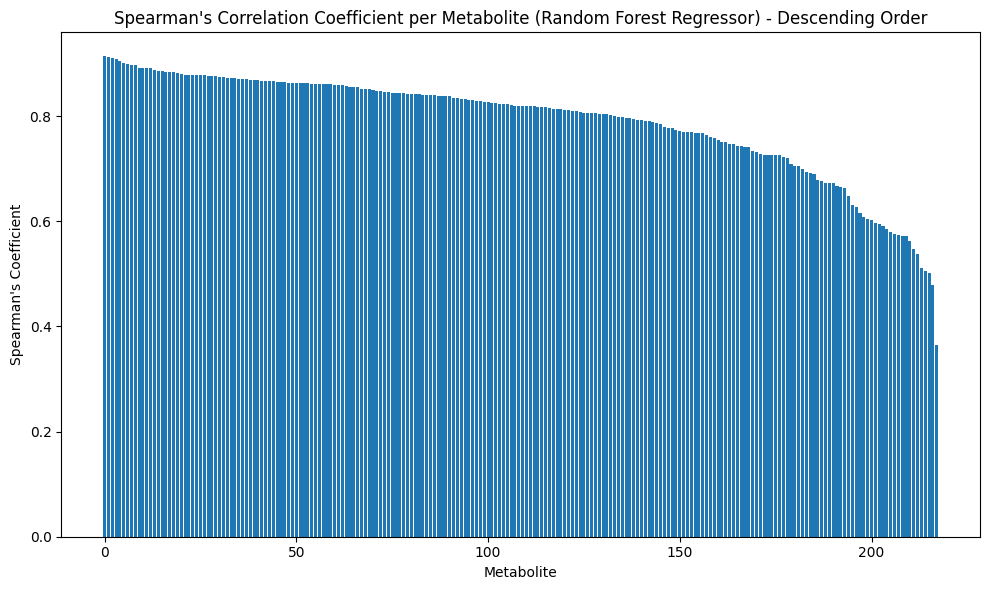

In [ ]:
plot_spearman_per_metabolite(model_rf, "Random Forest Regressor", X_test, y_test)

In [ ]:
spearman_rf = get_spearman_per_metabolite(model_rf, "Random Forest Regressor", X_test, y_test)
spearman_rf

,Metabolite,Spearman Coefficient
49,alanine,0.913839
131,lactate,0.913107
99,gluconate,0.910964
151,N-acetylalanine,0.907865
183,pyroglutamine,0.904757
...,...,...
50,alanylleucine,0.510502
77,cytidine 5'-diphosphocholine,0.506134
134,leucylglycine,0.501954
160,N6-acetyllysine,0.478894


In [ ]:
r2_rf.to_csv(f'{results_path}/r2_rf.csv', index = False)
spearman_rf.to_csv(f'{results_path}/spearman_rf.csv', index = False)

#XGBoost Regressor

In [ ]:
pipeline_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('model', MultiOutputRegressor(XGBRegressor(n_estimators = 100, max_depth = 5, subsample=1.0, random_state=0, tree_method = "hist", device = "cuda", predictor='auto', n_jobs = -1)))
])

model_xgb = pipeline_xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:58:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:58:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:58:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:58:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:58:04] WARNING: /workspace/src/learner.cc:738: 
Pa

In [ ]:
# pipeline_xgb = Pipeline([
#     ('imputer', SimpleImputer(strategy='mean')),
#     ('scaler', StandardScaler()),
#     ('pca', PCA(0.95)),
#     ('model', MultiOutputRegressor(XGBRegressor(random_state=0, tree_method = "hist", device = "cuda", predictor='auto', n_jobs = -1)))
# ])

In [ ]:
# xgb_param_grid = {
#     'model__estimator__n_estimators': [100, 150, 200, 250, 300, 500],
#     'model__estimator__max_depth': [5, 10, 20, 30, 50],
#     'model__estimator__subsample': [0.6, 0.8, 1.0]
# }


# xgb_grid_search = GridSearchCV(
#                                estimator=pipeline_xgb,
#                                param_grid=xgb_param_grid,
#                                scoring='neg_mean_squared_error',
#                                cv=5,
#                                verbose=3,
#                                n_jobs=-1
#                                )

In [ ]:
# xgb_grid_search.fit(X_train, y_train)

In [ ]:
# print("Best Parameters:", xgb_grid_search.best_params_)
# print("Best Score:", xgb_grid_search.best_score_)

In [ ]:
# model_xgb = xgb_grid_search.best_estimator_

In [ ]:
save_model(model = model_xgb, model_name = 'XGBoost Regressor')

In [ ]:
predictions_xgb = model_xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:729: UserWarning: [10:58:38] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


R-squared: 0.6133808493614197
Mean Squared Error (MSE): 2.7527213096618652
Root Mean Squared Error (RMSE): 1.6591326980268533


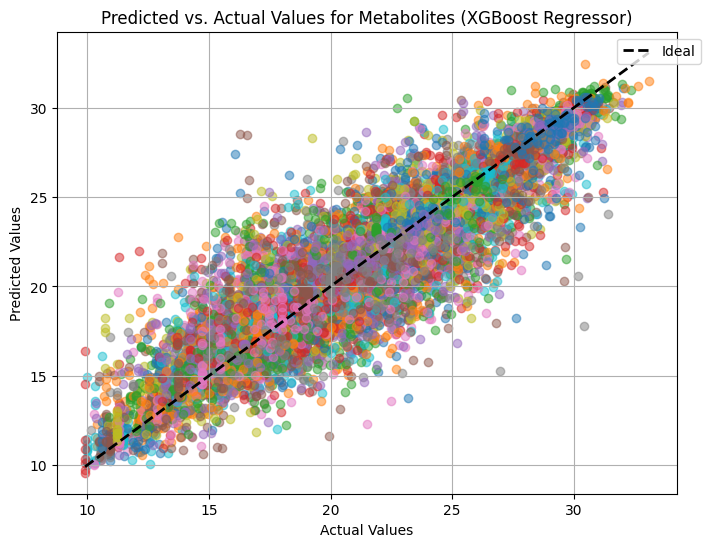

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = predictions_xgb, model_type = 'XGBoost Regressor')

Cross-validation scores: [-2.82290387 -2.1884706  -3.62588859 -2.0681076  -2.23100686 -4.53331661
 -2.52873302 -2.93878698 -1.88383806 -2.96022606]
Average score: -2.7781278252601624


/tmp/ipython-input-2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


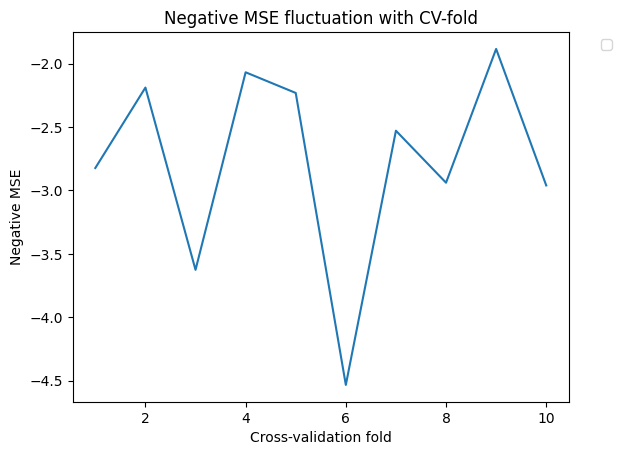

In [ ]:
plot_cv_scores(model_pipeline = model_xgb, model_type = 'Multi-output XGBoost Regressor', cv_fold = 10)

Cross-validation R-squared scores: [0.6140607  0.54177815 0.61842597 0.60174096 0.56922394 0.466553
 0.48776764 0.44410384 0.317119   0.54173601]
Average R-squared score: 0.5202509194612503


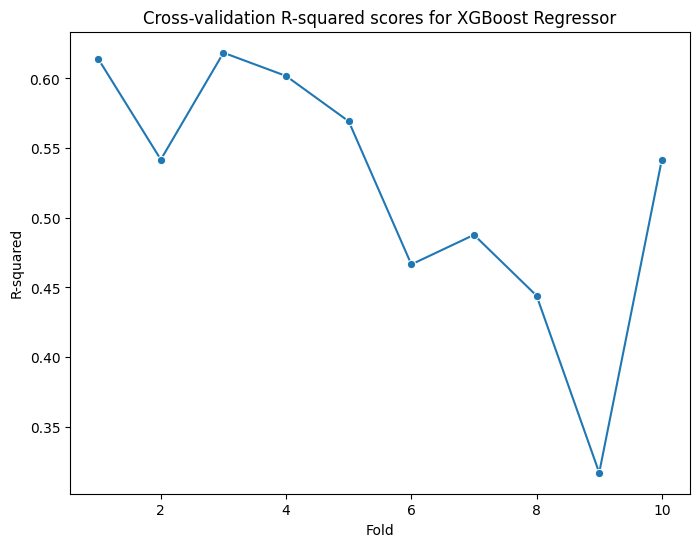

In [ ]:
get_r2_cross_val(model = model_xgb, model_name = 'XGBoost Regressor')

In [ ]:
get_metrics(y_predicted = predictions_xgb)

MSE: 2.7527213096618652
MAE: 1.1382555961608887
MedAE: 0.8038704795552988
Mean absolute percentage error: 5.794380615692698


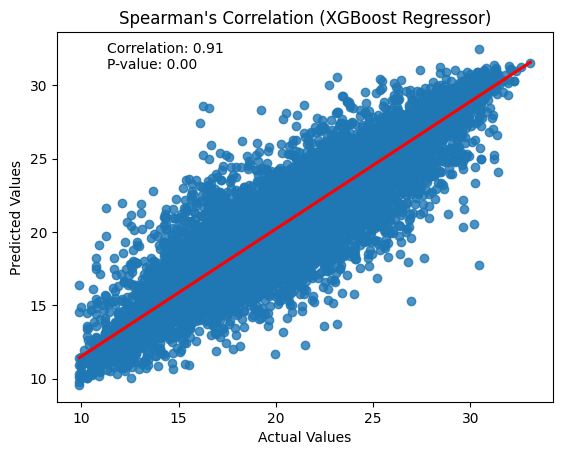

In [ ]:
get_spearman_correlation(model_predictions = predictions_xgb, model_name = 'XGBoost Regressor')

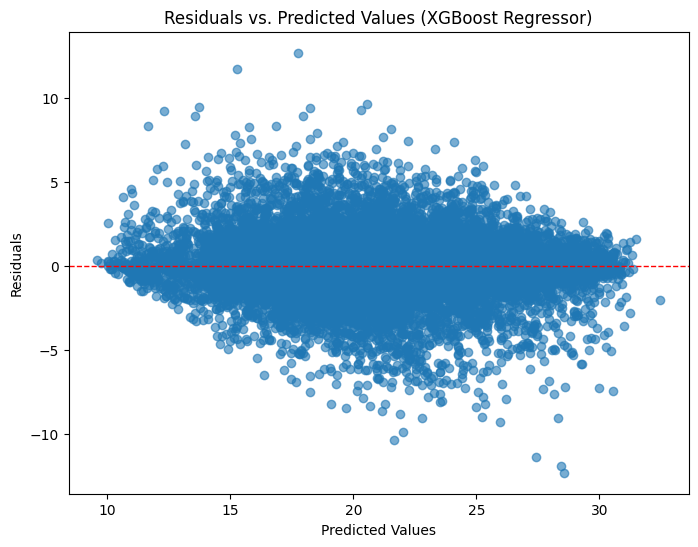

In [ ]:
get_residuals_vs_pred_plot(model_predictions = predictions_xgb, model_name = 'XGBoost Regressor')

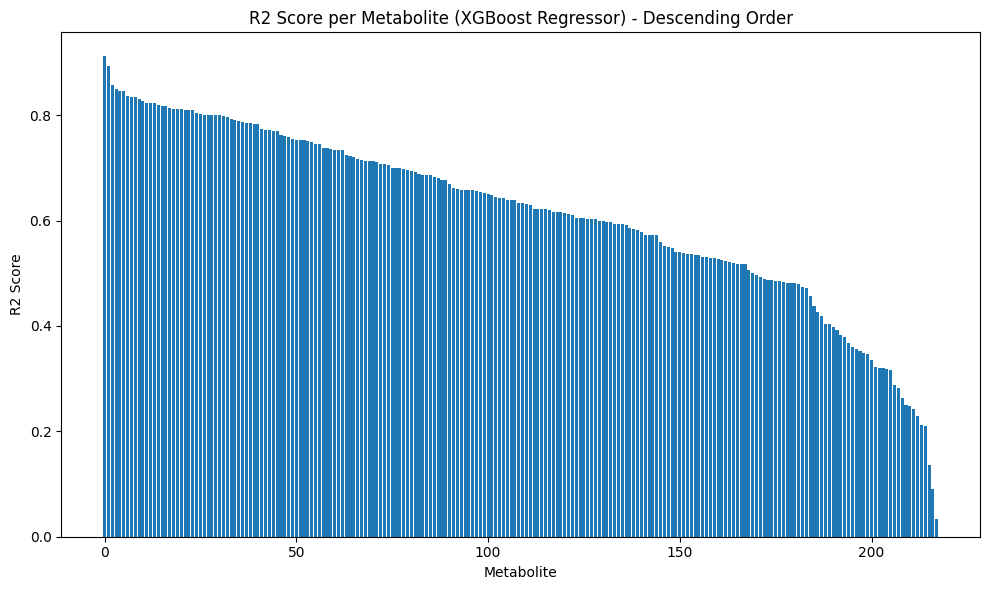

In [ ]:
plot_r2_per_metabolite(model_xgb, "XGBoost Regressor", X_test, y_test)

In [ ]:
r2_xgb = get_r2_per_metabolite(model_xgb, "XGBoost Regressor", X_test, y_test)
r2_xgb

,Metabolite,R2 Score
201,threonine,0.911754
195,stearoyl sphingomyelin (d18:1/18:0),0.894021
208,urea,0.858260
144,margarate (17:0),0.850668
133,leucine,0.846192
...,...,...
50,alanylleucine,0.212944
123,hypotaurine,0.209816
202,thymine,0.135670
126,inositol 1-phosphate (I1P),0.090039


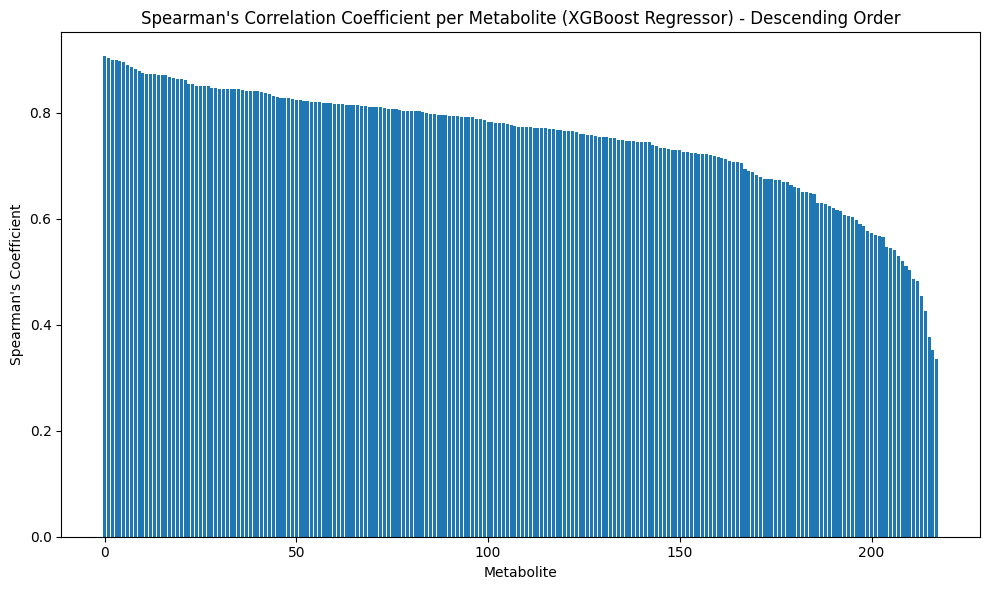

In [ ]:
plot_spearman_per_metabolite(model_xgb, "XGBoost Regressor", X_test, y_test)

In [ ]:
spearman_xgb = get_spearman_per_metabolite(model_xgb, "XGBoost Regressor", X_test, y_test)
spearman_xgb

,Metabolite,Spearman Coefficient
72,creatinine,0.905938
165,ornithine,0.902186
201,threonine,0.898856
139,malate,0.898396
212,xanthine,0.898070
...,...,...
114,glycylleucine,0.454233
50,alanylleucine,0.425977
126,inositol 1-phosphate (I1P),0.376299
134,leucylglycine,0.352972


In [ ]:
r2_xgb.to_csv(f'{results_path}/r2_xgb.csv', index = False)
spearman_xgb.to_csv(f'{results_path}/spearman_xgb.csv', index = False)

#LightGBM Regressor

In [ ]:
pipeline_lgbm = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('model', MultiOutputRegressor(LGBMRegressor(n_estimators = 100, max_depth= 5, num_leaves = 30, random_state=0, n_jobs = -1)))
])

model_lgbm = pipeline_lgbm.fit(X_train, y_train)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [ ]:
predictions_lgbm = model_lgbm.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

In [ ]:
# pipeline_lgbm = Pipeline([
#     ('imputer', SimpleImputer(strategy='mean')),
#     ('scaler', StandardScaler()),
#     ('pca', PCA(0.95)),
#     ('model', MultiOutputRegressor(LGBMRegressor(random_state=0, n_jobs = -1)))
# ])

# lgbm_param_grid = {
#     'model__estimator__n_estimators': [100, 150, 200, 250, 300, 500],
#     'model__estimator__max_depth': [5, 10, 20, 30, 50],
#     'model__estimator__num_leaves': [31, 50, 100, 200]
# }

# grid_search_lgbm = GridSearchCV(
#     estimator=pipeline_lgbm,
#     param_grid=lgbm_param_grid,
#     scoring='neg_mean_squared_error',
#     cv=5,
#     verbose=3,
#     n_jobs=-1
# )

In [ ]:
# grid_search_lgbm.fit(X_train, y_train)

In [ ]:
# print("Best Parameters:", grid_search_lgbm.best_params_)
# print("Best Score:", grid_search_lgbm.best_score_)

In [ ]:
# best_lgbm_model = grid_search_lgbm.best_estimator_

In [ ]:
# predictions_lgbm = best_lgbm_model.predict(X_test)

In [ ]:
save_model(model = model_lgbm, model_name = 'LightGBM Regressor')

R-squared: 0.6293866919069538
Mean Squared Error (MSE): 2.599058374768306
Root Mean Squared Error (RMSE): 1.612159537629048


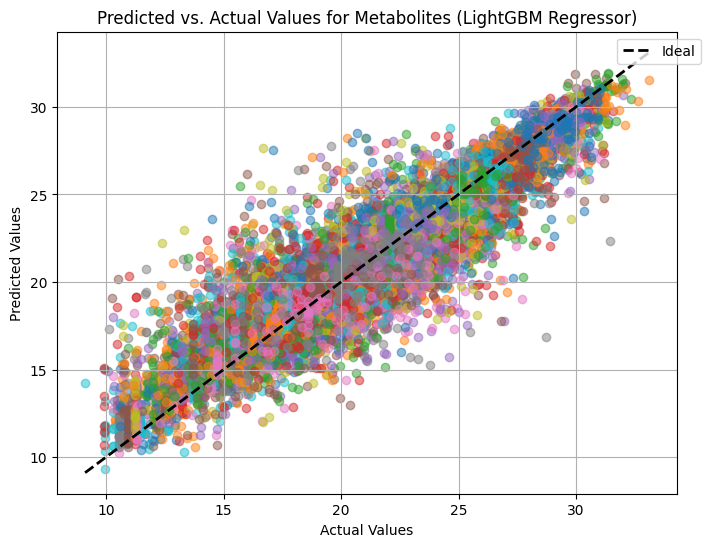

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = predictions_lgbm, model_type = 'LightGBM Regressor')

Cross-validation scores: [-2.71450215 -2.10802399 -3.19633572 -2.16487132 -3.07886044 -3.03602698
 -2.68919253 -2.86813868 -1.93186083 -2.65048947]
Average score: -2.6438302107430993


/tmp/ipython-input-2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


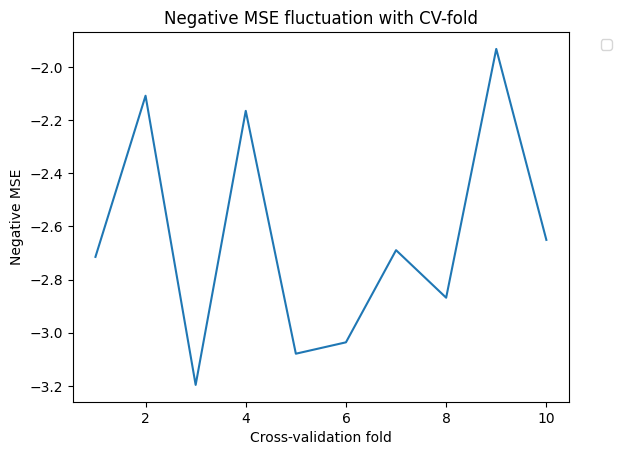

In [ ]:
plot_cv_scores(model_pipeline = model_lgbm, model_type = 'Multi-output LightGBM Regressor', cv_fold = 10)

Cross-validation R-squared scores: [0.62596605 0.53591626 0.58297123 0.5861634  0.55011049 0.58528234
 0.6243402  0.66778487 0.64559072 0.54378143]
Average R-squared score: 0.5947906973129775


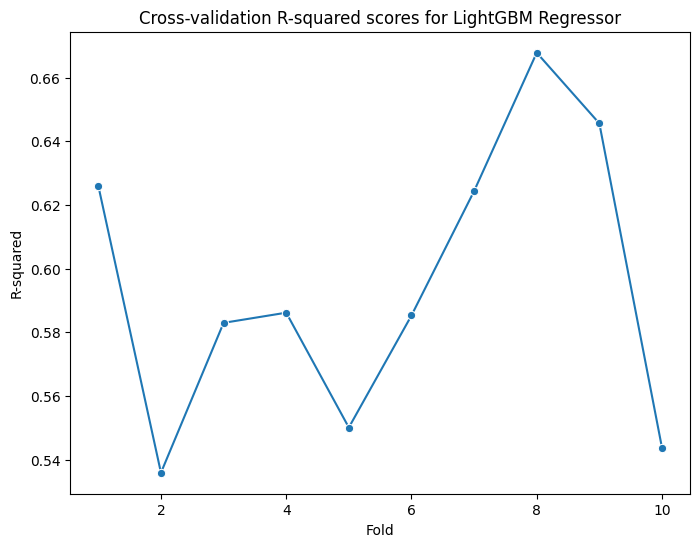

In [ ]:
get_r2_cross_val(model = model_lgbm, model_name = 'LightGBM Regressor')

In [ ]:
get_metrics(y_predicted = predictions_lgbm)

MSE: 2.8553142538225704
MAE: 1.1158815905792627
MedAE: 0.7168397437663124
Mean absolute percentage error: 5.452676117644438


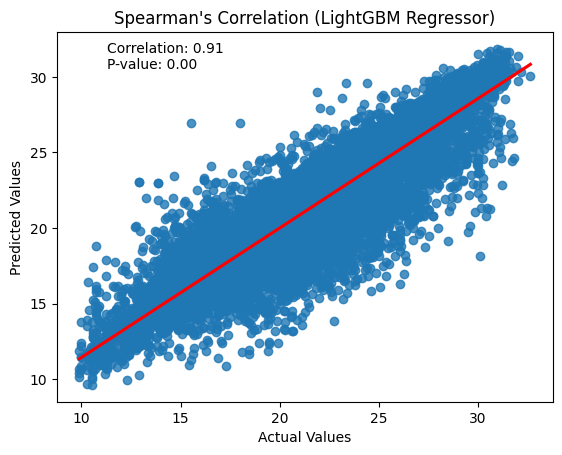

In [ ]:
get_spearman_correlation(model_predictions = predictions_lgbm, model_name = 'LightGBM Regressor')

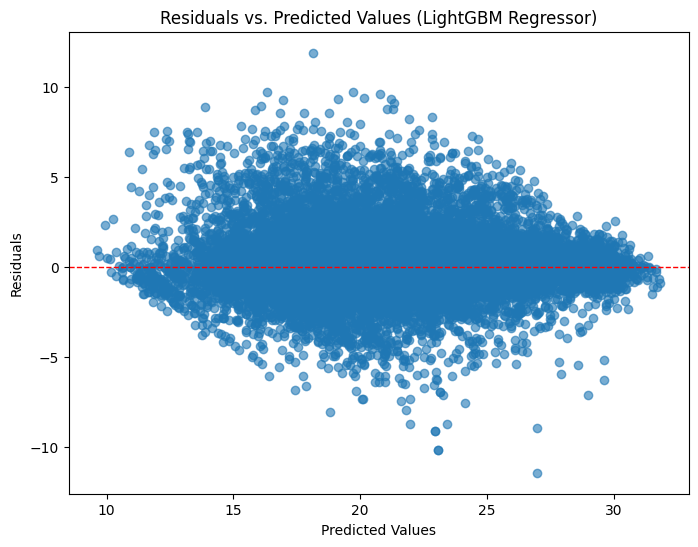

In [ ]:
get_residuals_vs_pred_plot(model_predictions = predictions_lgbm, model_name = 'LightGBM Regressor')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

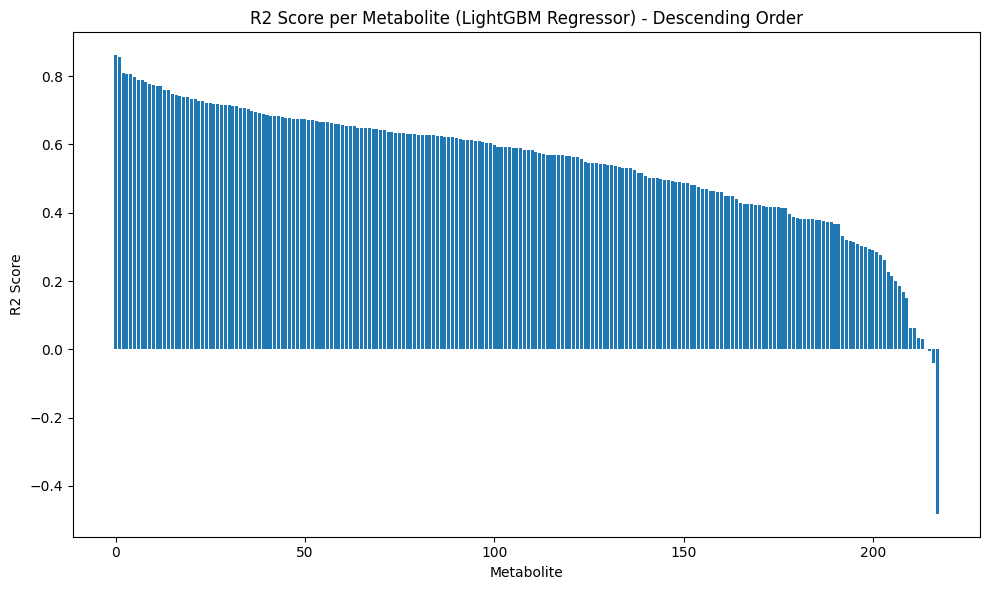

In [ ]:
plot_r2_per_metabolite(model_lgbm, "LightGBM Regressor", X_test, y_test)

In [ ]:
r2_lgbm = get_r2_per_metabolite(model_lgbm, "LightGBM Regressor", X_test, y_test)
r2_lgbm

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

,Metabolite,R2 Score
205,tyrosine,0.861155
108,glycerate,0.856445
195,stearoyl sphingomyelin (d18:1/18:0),0.809987
145,methionine,0.806284
104,glutamine,0.805201
...,...,...
0,"1,5-anhydroglucitol (1,5-AG)",0.030569
202,thymine,0.002165
50,alanylleucine,-0.006186
160,N6-acetyllysine,-0.039463


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

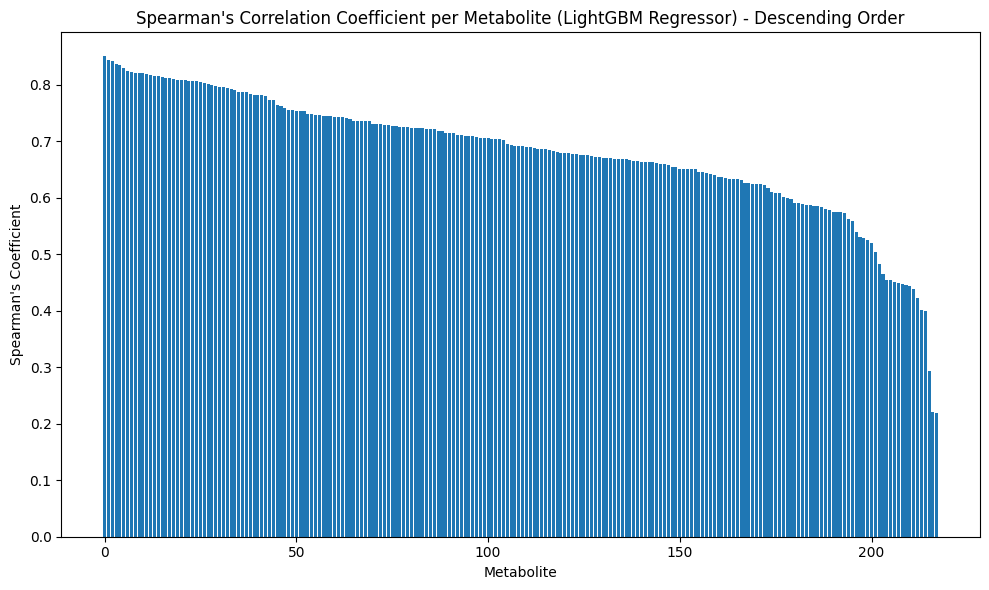

In [ ]:
plot_spearman_per_metabolite(model_lgbm, "LightGBM Regressor", X_test, y_test)

In [ ]:
spearman_lgbm = get_spearman_per_metabolite(model_lgbm, "LightGBM Regressor", X_test, y_test)
spearman_lgbm

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

,Metabolite,Spearman Coefficient
172,pantothenate,0.850422
72,creatinine,0.844704
205,tyrosine,0.842657
7,1-oleoyl-GPE (18:1),0.836211
139,malate,0.834982
...,...,...
47,adenosine 3'-monophosphate (3'-AMP),0.401155
88,erythritol,0.400476
0,"1,5-anhydroglucitol (1,5-AG)",0.293089
126,inositol 1-phosphate (I1P),0.221014


In [ ]:
r2_lgbm.to_csv(f'{results_path}/r2_lgbm.csv', index = False)
spearman_lgbm.to_csv(f'{results_path}/spearman_lgbm.csv', index = False)

#MLP Regressor

In [ ]:
from sklearn.neural_network import MLPRegressor

In [ ]:
pipeline_mlp = Pipeline([
    ('imputer', SimpleImputer(strategy = 'mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('model', MLPRegressor(random_state = 0, learning_rate = 'adaptive'))
])


param_grid_mlp = {
    'model__hidden_layer_sizes': [(100,), (50, 50), (100, 50, 25)],
    'model__activation': ['relu', 'tanh'],
    'model__solver': ['adam', 'sgd'],
    'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'model__batch_size': [32, 64, 128],
    'model__early_stopping': [True, False]
}


grid_search_mlp = GridSearchCV(
    estimator = pipeline_mlp,
    param_grid = param_grid_mlp,
    scoring = 'neg_mean_squared_error',
    verbose = 3,
    n_jobs = -1
)

grid_search_mlp.fit(X_train, y_train)

Fitting 5 folds for each of 504 candidates, totalling 2520 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
209 fits failed out of a total of 2520.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
209 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, 

GridSearchCV(estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model',
                                        MLPRegressor(learning_rate='adaptive',
                                                     random_state=0))]),
             n_jobs=-1,
             param_grid={'model__activation': ['relu', 'tanh'],
                         'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
                         'model__batch_size': [32, 64, 128],
                         'model__early_stopping': [True, False],
                         'model__hidden_layer_sizes': [(100,), (50, 50),
                                                       (100, 50, 25)],
                         'model__solver': ['adam', 'sgd']},
             scoring='neg_mean_squared_error', verbose=3)

In [ ]:
print("Best Parameters:", grid_search_mlp.best_params_)
print("Best Score:", grid_search_mlp.best_score_)

Best Parameters: {'model__activation': 'tanh', 'model__alpha': 100, 'model__batch_size': 64, 'model__early_stopping': True, 'model__hidden_layer_sizes': (100,), 'model__solver': 'sgd'}
Best Score: -2.449466546045181


In [ ]:
best_mlp_model = grid_search_mlp.best_estimator_

In [ ]:
save_model(model = best_mlp_model, model_name = 'MLP Regressor')

In [ ]:
predictions_mlp = best_mlp_model.predict(X_test)

R-squared: 0.5721815638375581
Mean Squared Error (MSE): 2.5378430919439654
Root Mean Squared Error (RMSE): 1.5930609190937945


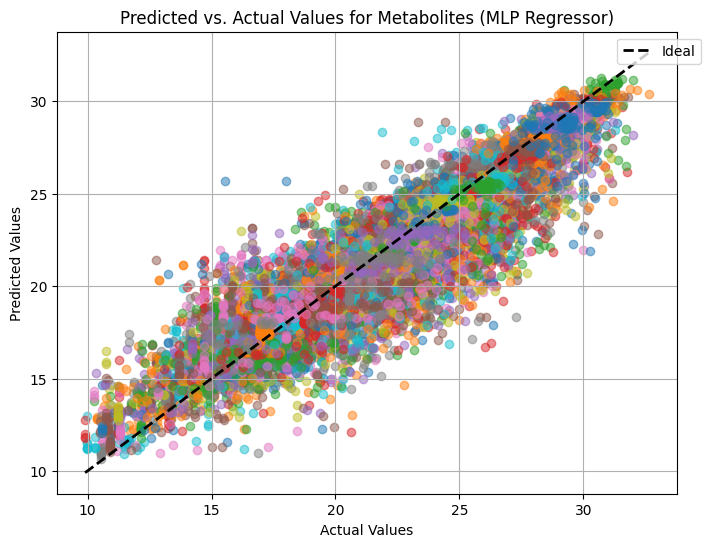

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = predictions_mlp, model_type = 'MLP Regressor')

Cross-validation scores: [-2.24015831 -2.47210694 -2.17680818 -2.36911938 -2.07167356 -2.77461885
 -2.2967649  -1.88562564 -2.43194082 -2.27391316]
Average score: -2.2992729741240487


/tmp/ipython-input-2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


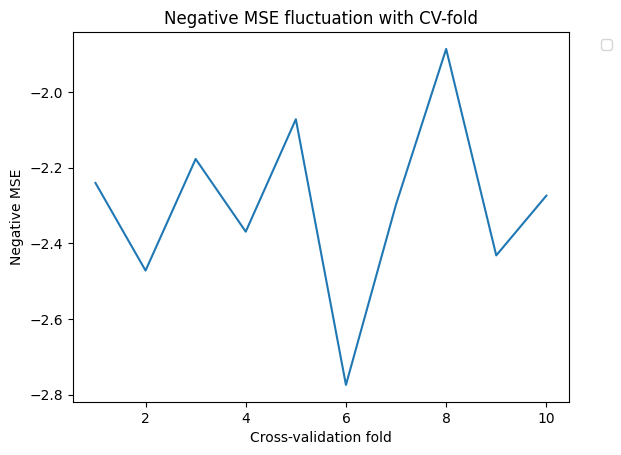

In [ ]:
plot_cv_scores(model_pipeline = best_mlp_model, model_type = 'MLP Regressor', cv_fold = 10)

Cross-validation R-squared scores: [0.58218564 0.6307697  0.69943304 0.5591292  0.66251861 0.56304314
 0.58545128 0.67557411 0.5749838  0.57265256]
Average R-squared score: 0.61057410975512


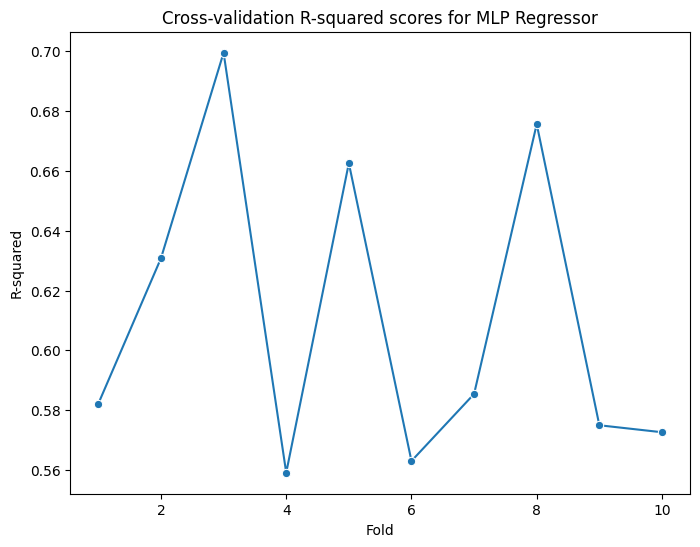

In [ ]:
get_r2_cross_val(model = best_mlp_model, model_name = 'MLP Regressor')

In [ ]:
get_metrics(y_predicted = predictions_mlp)

MSE: 2.5378430919439654
MAE: 1.129974315227339
MedAE: 0.8252543918362026
Mean absolute percentage error: 5.522738827038412


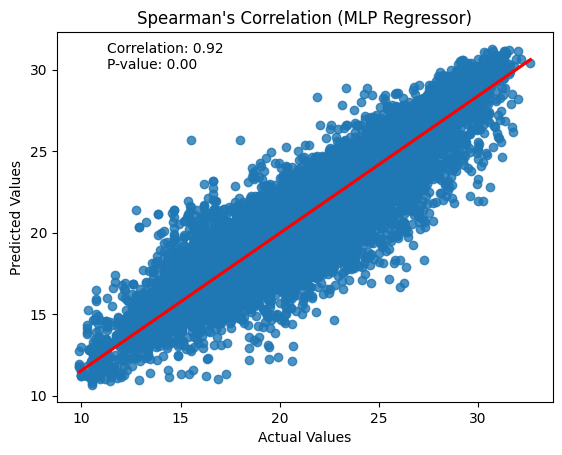

In [ ]:
get_spearman_correlation(model_predictions = predictions_mlp, model_name = 'MLP Regressor')

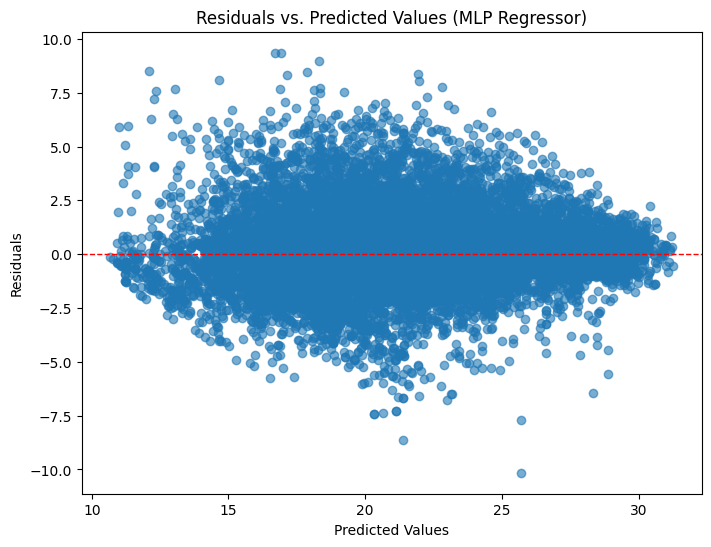

In [ ]:
get_residuals_vs_pred_plot(model_predictions = predictions_mlp, model_name = 'MLP Regressor')

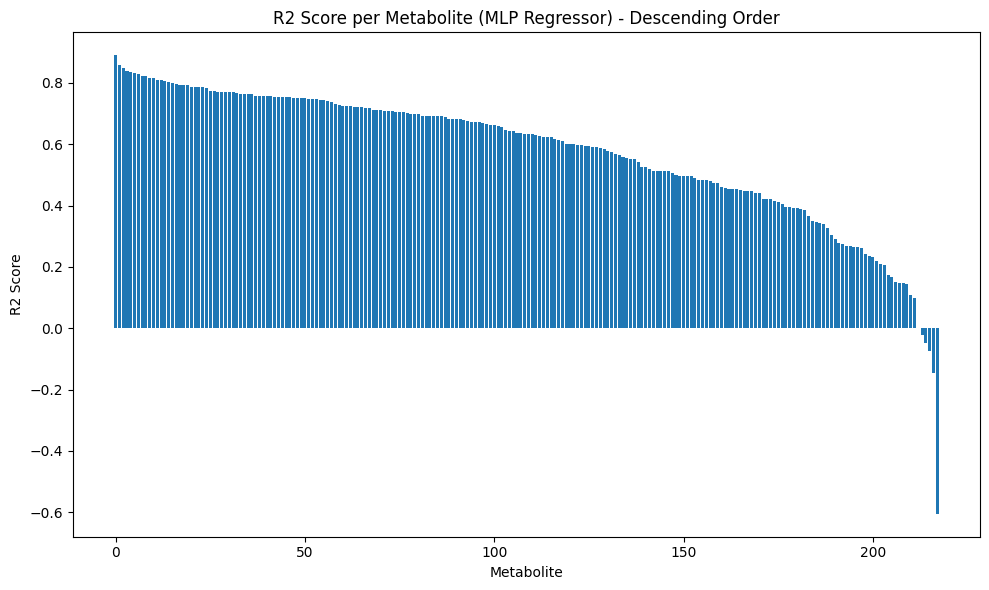

In [ ]:
plot_r2_per_metabolite(best_mlp_model, "MLP Regressor", X_test, y_test)

In [ ]:
r2_mlp = get_r2_per_metabolite(best_mlp_model, "MLP Regressor", X_test, y_test)
r2_mlp

,Metabolite,R2 Score
205,tyrosine,0.890177
104,glutamine,0.858074
108,glycerate,0.848693
128,isoleucine,0.840232
145,methionine,0.835296
...,...,...
0,"1,5-anhydroglucitol (1,5-AG)",-0.020484
50,alanylleucine,-0.049459
126,inositol 1-phosphate (I1P),-0.072690
202,thymine,-0.146907


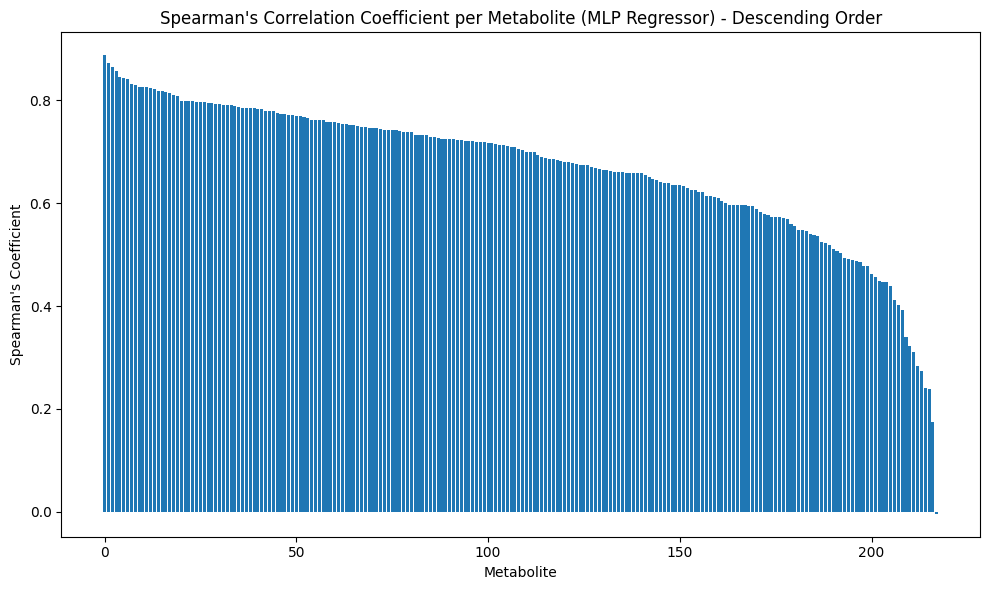

In [ ]:
plot_spearman_per_metabolite(best_mlp_model, "MLP Regressor", X_test, y_test)

In [ ]:
spearman_mlp = get_spearman_per_metabolite(best_mlp_model, "MLP Regressor", X_test, y_test)
spearman_mlp

,Metabolite,Spearman Coefficient
72,creatinine,0.888039
172,pantothenate,0.872905
120,hippurate,0.866031
182,pseudouridine,0.857403
158,N-acetylthreonine,0.845591
...,...,...
97,gamma-glutamylphenylalanine,0.273710
103,"glutamate, gamma-methyl ester",0.239480
134,leucylglycine,0.237629
126,inositol 1-phosphate (I1P),0.174192


In [ ]:
r2_mlp.to_csv(f'{results_path}/r2_mlp.csv', index = False)
spearman_mlp.to_csv(f'{results_path}/spearman_mlp.csv', index = False)